In [3]:
# 01 — Import Libraries
# Purpose: Import the libraries needed for data loading and inspection
import pandas as pd
import numpy as np

In [ ]:
# 02 — Define Dataset Paths
# Purpose: Define the paths to the FD001 raw dataset files

In [4]:
train_path = "../data/raw/train_FD001.txt"
test_path = "../data/raw/test_FD001.txt"
rul_path = "../data/raw/RUL_FD001.txt"

In [ ]:
# 03 — Define C-MAPSS Column Names
# Purpose: Create meaningful column names for the raw sensor data

In [5]:
columns = [
    "Engine_ID",
    "Cycle",
    "Setting_1",
    "Setting_2",
    "Setting_3",
    "Sensor_1",
    "Sensor_2",
    "Sensor_3",
    "Sensor_4",
    "Sensor_5",
    "Sensor_6",
    "Sensor_7",
    "Sensor_8",
    "Sensor_9",
    "Sensor_10",
    "Sensor_11",
    "Sensor_12",
    "Sensor_13",
    "Sensor_14",
    "Sensor_15",
    "Sensor_16",
    "Sensor_17",
    "Sensor_18",
    "Sensor_19",
    "Sensor_20",
    "Sensor_21"
]

len(columns)

26

In [ ]:
# 04 — Load Training Data
# Purpose: Load the FD001 training trajectories into a DataFrame

In [6]:
train_df = pd.read_csv(
    train_path,
    sep=r"\s+",
    header=None,
    names=columns
)

train_df.head()

,Engine_ID,Cycle,Setting_1,Setting_2,Setting_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,...,Sensor_12,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [8]:
# 05 — Load Test Data
# Purpose: Load the FD001 test trajectories into a DataFrame

In [7]:
test_df = pd.read_csv(
    test_path,
    sep=r"\s+",
    header=None,
    names=columns
)

test_df.head()

,Engine_ID,Cycle,Setting_1,Setting_2,Setting_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,...,Sensor_12,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [9]:
# 06 — Load Test RUL Values
# Purpose: Load the true Remaining Useful Life values for test engines

In [10]:
rul_df = pd.read_csv(
    rul_path,
    sep=r"\s+",
    header=None,
    names=["RUL"]
)

rul_df.head()

,RUL
0,112
1,98
2,69
3,82
4,91


In [ ]:
# 07 — Check Dataset Shapes
# Purpose: Inspect the number of rows and columns in each dataset

In [11]:
print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)
print("RUL data shape:", rul_df.shape)

Training data shape: (20631, 26)
Test data shape: (13096, 26)
RUL data shape: (100, 1)


In [ ]:
# 08 — Check Number of Engines
# Purpose: Count unique engines in the training and test datasets

In [12]:
print("Number of training engines:", train_df["Engine_ID"].nunique())
print("Number of test engines:", test_df["Engine_ID"].nunique())

Number of training engines: 100
Number of test engines: 100


In [13]:
# 09 — Inspect Engine Operating Cycles
# Purpose: Examine how many cycles each training engine completed

In [14]:
cycles_per_engine = train_df.groupby("Engine_ID")["Cycle"].max()

print(cycles_per_engine.head(10))
print()
print("Minimum cycles:", cycles_per_engine.min())
print("Maximum cycles:", cycles_per_engine.max())
print("Average cycles:", cycles_per_engine.mean())

Engine_ID
1     192
2     287
3     179
4     189
5     269
6     188
7     259
8     150
9     201
10    222
Name: Cycle, dtype: int64

Minimum cycles: 128
Maximum cycles: 362
Average cycles: 206.31


In [15]:
# 10 — Dataset Information
# Purpose: Inspect data types and memory structure

In [16]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Engine_ID  20631 non-null  int64  
 1   Cycle      20631 non-null  int64  
 2   Setting_1  20631 non-null  float64
 3   Setting_2  20631 non-null  float64
 4   Setting_3  20631 non-null  float64
 5   Sensor_1   20631 non-null  float64
 6   Sensor_2   20631 non-null  float64
 7   Sensor_3   20631 non-null  float64
 8   Sensor_4   20631 non-null  float64
 9   Sensor_5   20631 non-null  float64
 10  Sensor_6   20631 non-null  float64
 11  Sensor_7   20631 non-null  float64
 12  Sensor_8   20631 non-null  float64
 13  Sensor_9   20631 non-null  float64
 14  Sensor_10  20631 non-null  float64
 15  Sensor_11  20631 non-null  float64
 16  Sensor_12  20631 non-null  float64
 17  Sensor_13  20631 non-null  float64
 18  Sensor_14  20631 non-null  float64
 19  Sensor_15  20631 non-null  float64
 20  Sensor

In [17]:
# 11 — Statistical Summary
# Purpose: Generate descriptive statistics for the training data

In [18]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine_ID,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
Cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
Setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
Setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
Setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
Sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
Sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
Sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
Sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
Sensor_5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200


In [19]:
# 12 — Missing Value Check
# Purpose: Identify missing values in the training dataset

In [20]:
missing_values = train_df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [ ]:
# 13 — Duplicate Row Check
# Purpose: Identify duplicated observations in the training data

In [21]:
print("Number of duplicated rows:", train_df.duplicated().sum())

Number of duplicated rows: 0


In [ ]:
# 14 — Engine ID Range Check
# Purpose: Verify the engine identifiers in the training dataset

In [22]:
print("Minimum Engine ID:", train_df["Engine_ID"].min())
print("Maximum Engine ID:", train_df["Engine_ID"].max())
print("Unique Engine IDs:", train_df["Engine_ID"].nunique())

Minimum Engine ID: 1
Maximum Engine ID: 100
Unique Engine IDs: 100


In [ ]:
# 15 — Inspect Engine Time-Series Progression
# Purpose: Verify cycle progression for individual engine trajectories

In [23]:
engine_1 = train_df[train_df["Engine_ID"] == 1]

print(engine_1[["Engine_ID", "Cycle"]].head(10))
print()
print(engine_1[["Engine_ID", "Cycle"]].tail(10))

   Engine_ID  Cycle
0          1      1
1          1      2
2          1      3
3          1      4
4          1      5
5          1      6
6          1      7
7          1      8
8          1      9
9          1     10

     Engine_ID  Cycle
182          1    183
183          1    184
184          1    185
185          1    186
186          1    187
187          1    188
188          1    189
189          1    190
190          1    191
191          1    192


In [ ]:
# 16 — Import Visualization Libraries
# Purpose: Import libraries used to visualize sensor behavior
#          and degradation trends over operating cycles

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 17 — Define Sensor Columns
# Purpose: Create a list containing all sensor feature names

In [25]:
sensor_cols = [f"Sensor_{i}" for i in range(1, 22)]

print("Number of sensors:", len(sensor_cols))
print(sensor_cols)

Number of sensors: 21
['Sensor_1', 'Sensor_2', 'Sensor_3', 'Sensor_4', 'Sensor_5', 'Sensor_6', 'Sensor_7', 'Sensor_8', 'Sensor_9', 'Sensor_10', 'Sensor_11', 'Sensor_12', 'Sensor_13', 'Sensor_14', 'Sensor_15', 'Sensor_16', 'Sensor_17', 'Sensor_18', 'Sensor_19', 'Sensor_20', 'Sensor_21']


In [ ]:
# 18 — Analyze Sensor Variability
# Purpose: Measure the standard deviation and number of unique
#          values for every sensor

In [26]:
sensor_variability = pd.DataFrame({
    "Standard_Deviation": train_df[sensor_cols].std(),
    "Unique_Values": train_df[sensor_cols].nunique()
})

sensor_variability = sensor_variability.sort_values(
    "Standard_Deviation"
)

display(sensor_variability)

,Standard_Deviation,Unique_Values
Sensor_1,0.000000e+00,1
Sensor_10,0.000000e+00,1
Sensor_19,0.000000e+00,1
Sensor_18,0.000000e+00,1
Sensor_16,3.469531e-18,1
Sensor_5,5.329200e-15,1
Sensor_6,1.388985e-03,2
Sensor_15,3.750504e-02,1918
Sensor_8,7.098548e-02,53
Sensor_13,7.191892e-02,56


In [ ]:
# 18.1 — Identify Constant Sensors
# Purpose: Identify sensors that have no variation across
#          the entire training dataset

In [27]:
constant_sensors = sensor_variability[
    sensor_variability["Standard_Deviation"] == 0
].index.tolist()

variable_sensors = [
    sensor for sensor in sensor_cols
    if sensor not in constant_sensors
]

print("Constant sensors:")
print(constant_sensors)

print("\nNumber of constant sensors:", len(constant_sensors))
print("Number of variable sensors:", len(variable_sensors))

Constant sensors:
['Sensor_1', 'Sensor_10', 'Sensor_19', 'Sensor_18']

Number of constant sensors: 4
Number of variable sensors: 17


In [ ]:
# 19 — Visualize Sensor Trends for Engine 1
# Purpose: Observe how sensor measurements change across
#          operating cycles for a single engine trajectory

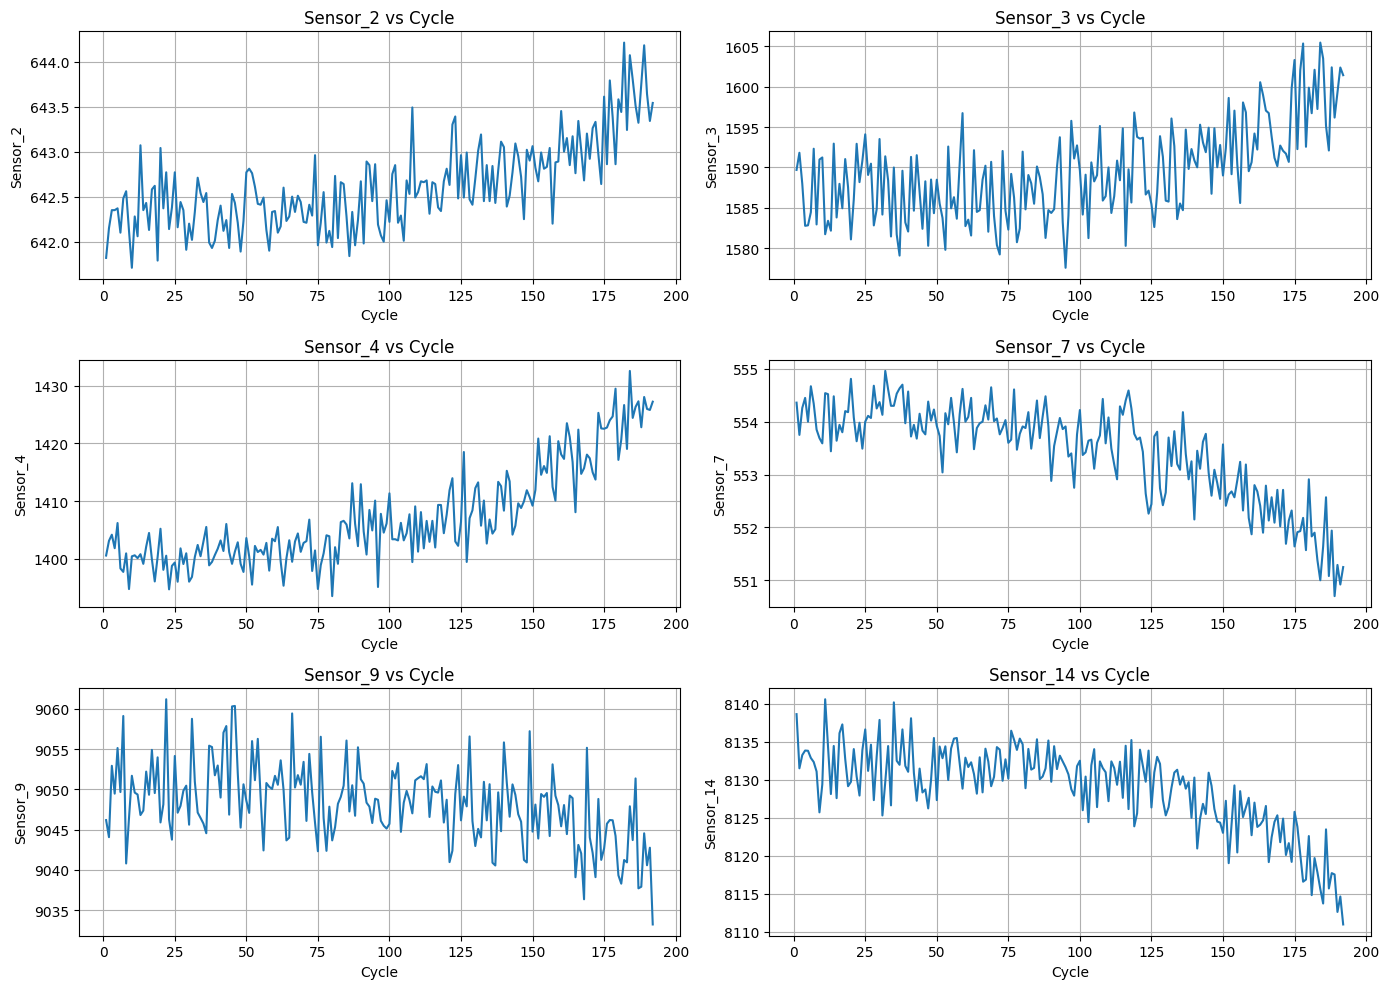

In [28]:
engine_1 = train_df[train_df["Engine_ID"] == 1]

selected_sensors = [
    "Sensor_2",
    "Sensor_3",
    "Sensor_4",
    "Sensor_7",
    "Sensor_9",
    "Sensor_14"
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 10)
)

axes = axes.flatten()

for ax, sensor in zip(axes, selected_sensors):
    ax.plot(
        engine_1["Cycle"],
        engine_1[sensor]
    )
    
    ax.set_title(f"{sensor} vs Cycle")
    ax.set_xlabel("Cycle")
    ax.set_ylabel(sensor)
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# 20 — Analyze Operating Conditions
# Purpose: Visualize how operating settings change across
#          cycles for Engine 1

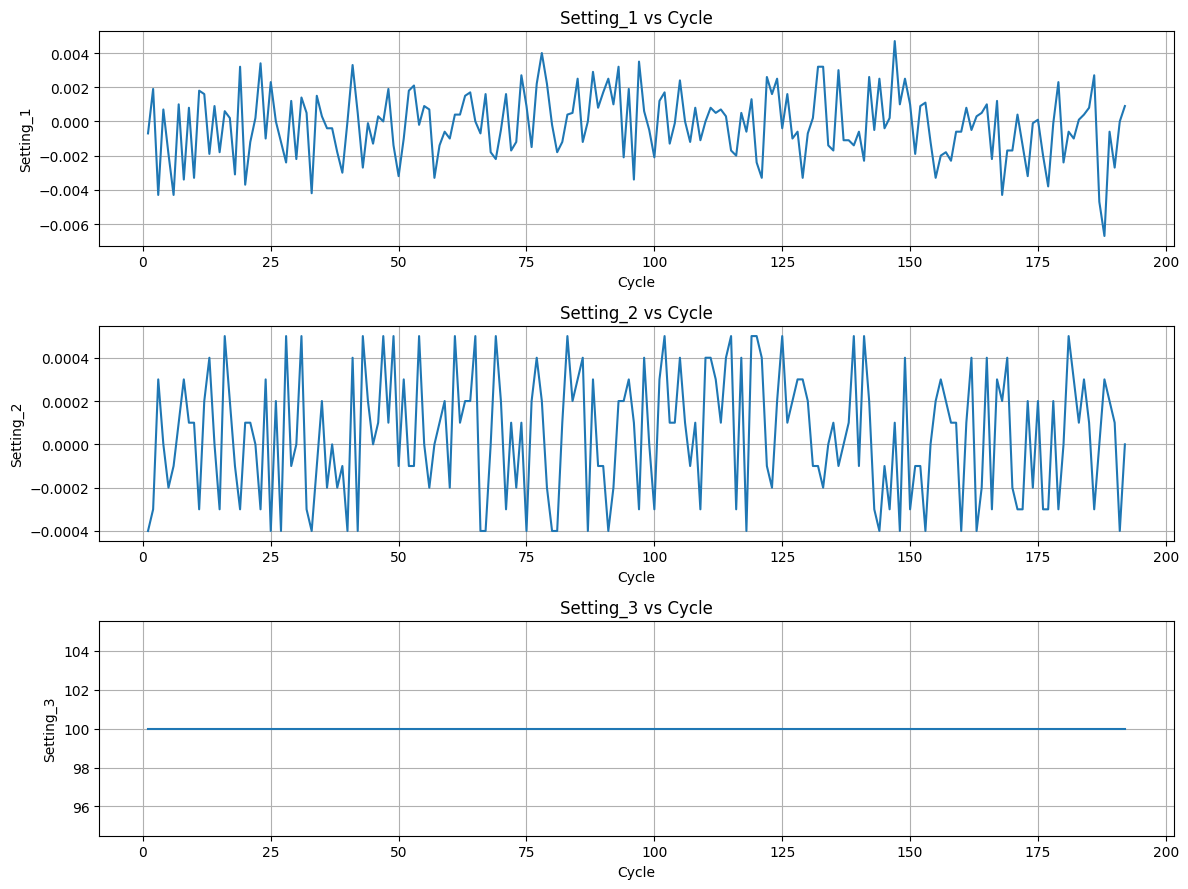

In [29]:
settings = [
    "Setting_1",
    "Setting_2",
    "Setting_3"
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 9)
)

for ax, setting in zip(axes, settings):
    ax.plot(
        engine_1["Cycle"],
        engine_1[setting]
    )
    
    ax.set_title(f"{setting} vs Cycle")
    ax.set_xlabel("Cycle")
    ax.set_ylabel(setting)
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# 21 — Calculate Sensor-Cycle Correlation
# Purpose: Measure the linear relationship between each sensor
#          and the operating cycle

In [30]:
sensor_cycle_corr = train_df[sensor_cols].corrwith(
    train_df["Cycle"]
)

sensor_cycle_corr = sensor_cycle_corr.sort_values()

display(sensor_cycle_corr)

c:\Users\win 10-11\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\win 10-11\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Sensor_12   -6.113536e-01
Sensor_7    -5.959136e-01
Sensor_21   -5.859234e-01
Sensor_20   -5.835969e-01
Sensor_16   -4.553716e-16
Sensor_5     1.305633e-15
Sensor_6     1.059800e-01
Sensor_14    3.703236e-01
Sensor_9     4.439993e-01
Sensor_8     4.759773e-01
Sensor_13    4.775230e-01
Sensor_3     5.439470e-01
Sensor_2     5.498980e-01
Sensor_17    5.669949e-01
Sensor_15    5.886758e-01
Sensor_4     6.245772e-01
Sensor_11    6.343845e-01
Sensor_1              NaN
Sensor_10             NaN
Sensor_18             NaN
Sensor_19             NaN
dtype: float64

In [ ]:
# 22 — Rank Sensors by Trend Strength
# Purpose: Rank sensors according to the absolute strength
#          of their correlation with operating cycle

In [31]:
sensor_trend_strength = sensor_cycle_corr.abs().sort_values(
    ascending=False
)

display(sensor_trend_strength)

Sensor_11    6.343845e-01
Sensor_4     6.245772e-01
Sensor_12    6.113536e-01
Sensor_7     5.959136e-01
Sensor_15    5.886758e-01
Sensor_21    5.859234e-01
Sensor_20    5.835969e-01
Sensor_17    5.669949e-01
Sensor_2     5.498980e-01
Sensor_3     5.439470e-01
Sensor_13    4.775230e-01
Sensor_8     4.759773e-01
Sensor_9     4.439993e-01
Sensor_14    3.703236e-01
Sensor_6     1.059800e-01
Sensor_5     1.305633e-15
Sensor_16    4.553716e-16
Sensor_1              NaN
Sensor_10             NaN
Sensor_18             NaN
Sensor_19             NaN
dtype: float64

In [ ]:
# 23 — Visualize Top Sensor Trend Candidates
# Purpose: Visualize the sensors with the strongest absolute
#          correlation with operating cycle

Top sensor candidates:
['Sensor_11', 'Sensor_4', 'Sensor_12', 'Sensor_7', 'Sensor_15', 'Sensor_21']


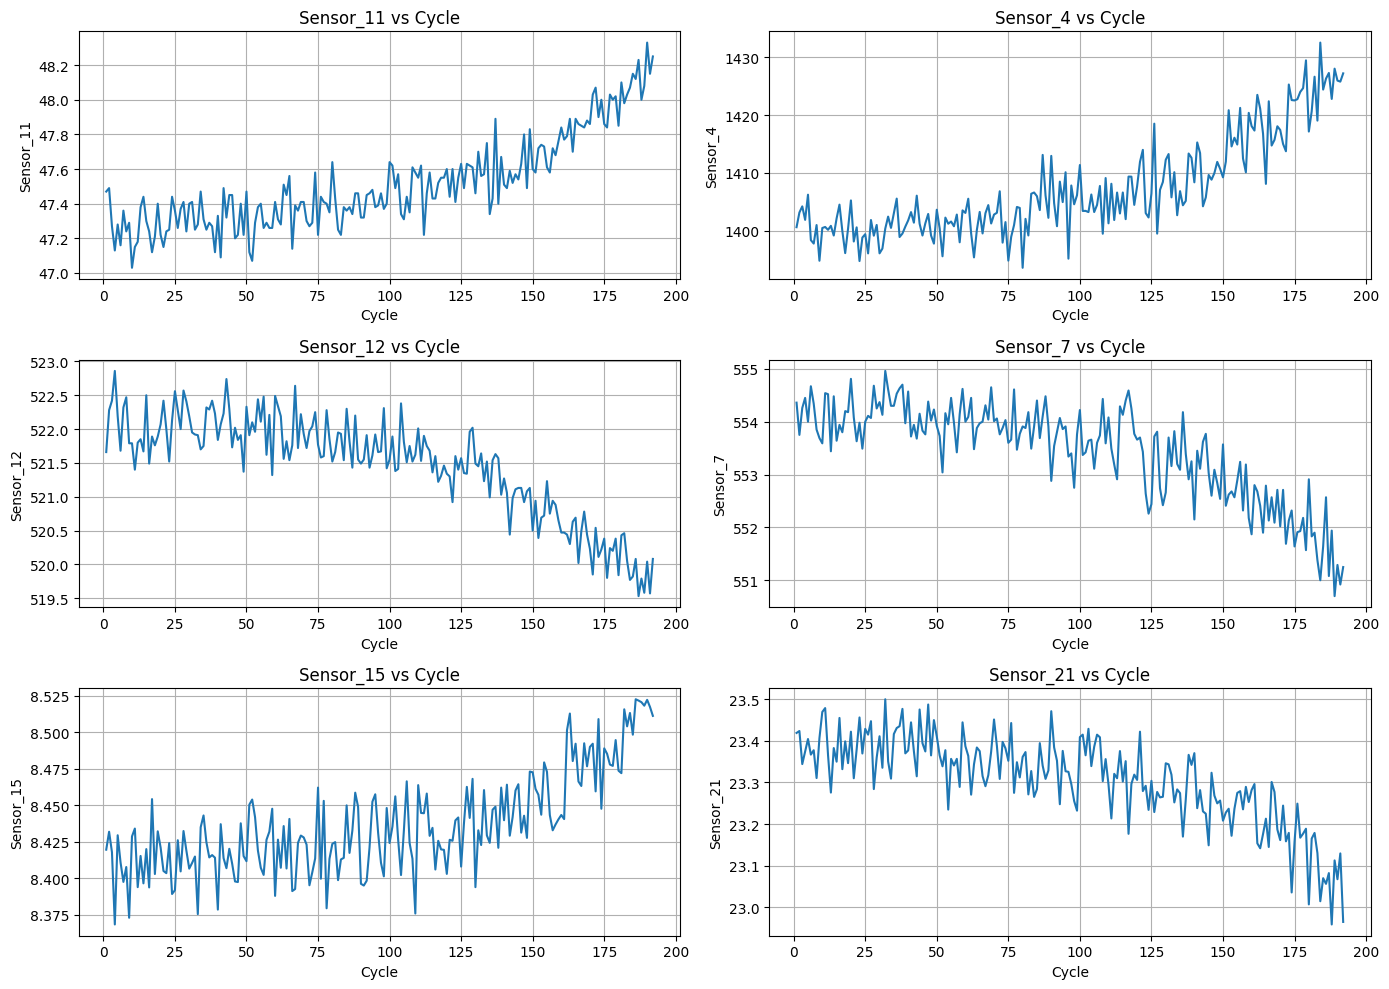

In [32]:
top_sensors = sensor_trend_strength.head(6).index.tolist()

print("Top sensor candidates:")
print(top_sensors)

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 10)
)

axes = axes.flatten()

for ax, sensor in zip(axes, top_sensors):
    ax.plot(
        engine_1["Cycle"],
        engine_1[sensor]
    )
    
    ax.set_title(f"{sensor} vs Cycle")
    ax.set_xlabel("Cycle")
    ax.set_ylabel(sensor)
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# 24 — Compare Sensor Trends Across Multiple Engines
# Purpose: Check whether the selected sensor trends are
#          consistent across different engine trajectories

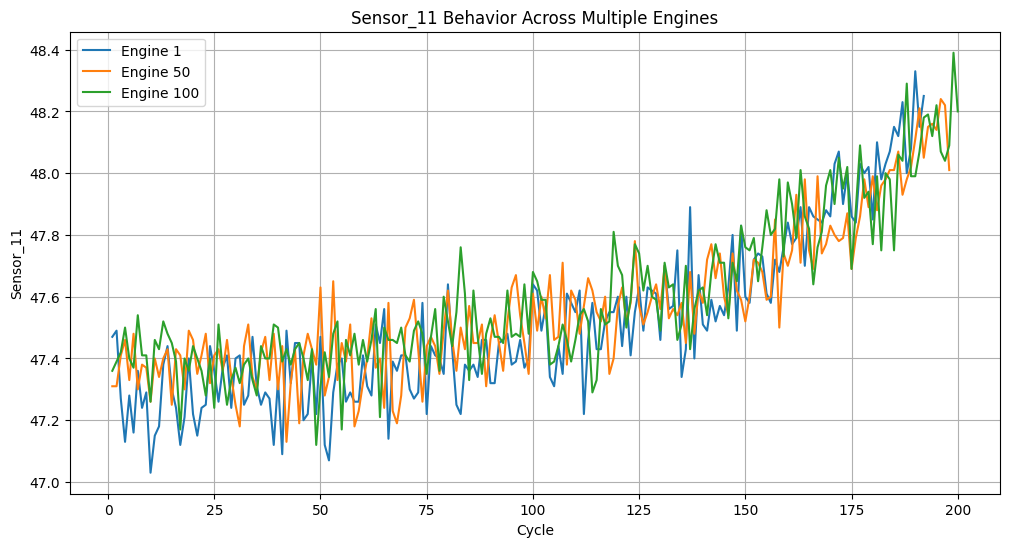

In [33]:
comparison_engines = [1, 50, 100]

comparison_sensor = top_sensors[0]

plt.figure(figsize=(12, 6))

for engine_id in comparison_engines:
    
    engine_data = train_df[
        train_df["Engine_ID"] == engine_id
    ]
    
    plt.plot(
        engine_data["Cycle"],
        engine_data[comparison_sensor],
        label=f"Engine {engine_id}"
    )

plt.title(
    f"{comparison_sensor} Behavior Across Multiple Engines"
)

plt.xlabel("Cycle")
plt.ylabel(comparison_sensor)
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# 25 — Sensor Distribution Analysis
# Purpose: Analyze the value distributions of the most relevant
#          sensors identified during the previous EDA stage

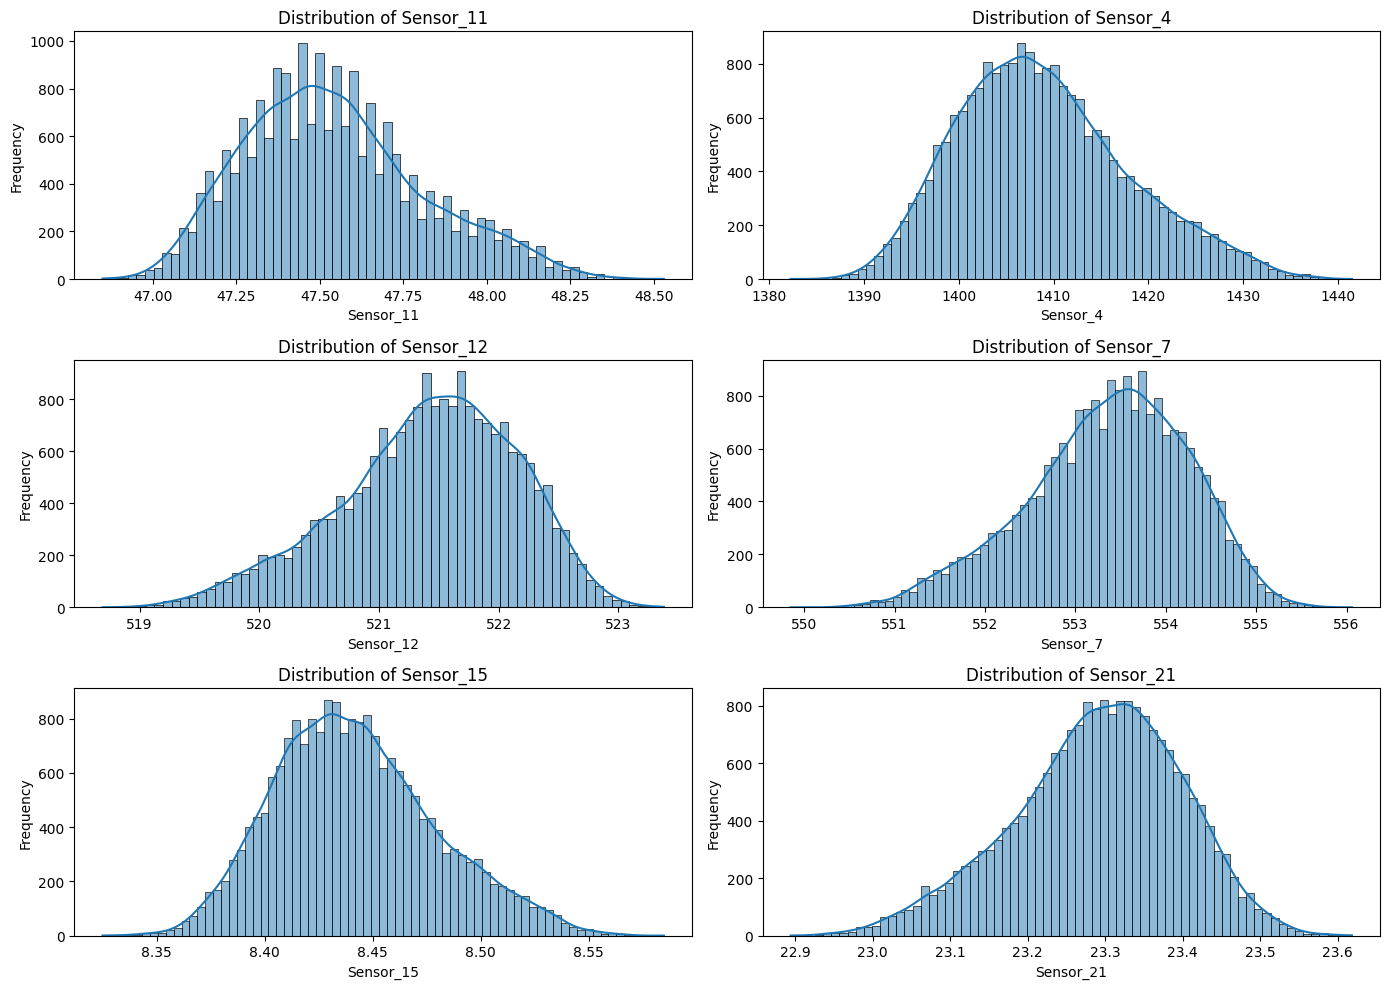

In [34]:
top_sensors = sensor_trend_strength.head(6).index.tolist()

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 10)
)

axes = axes.flatten()

for ax, sensor in zip(axes, top_sensors):
    sns.histplot(
        data=train_df,
        x=sensor,
        kde=True,
        ax=ax
    )
    
    ax.set_title(f"Distribution of {sensor}")
    ax.set_xlabel(sensor)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
# 26 — Detect Sensor Outliers Using IQR
# Purpose: Identify potential outliers in variable sensors
#          using the Interquartile Range method

In [35]:
outlier_summary = []

for sensor in variable_sensors:
    
    Q1 = train_df[sensor].quantile(0.25)
    Q3 = train_df[sensor].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = train_df[
        (train_df[sensor] < lower_bound) |
        (train_df[sensor] > upper_bound)
    ]
    
    outlier_summary.append({
        "Sensor": sensor,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": len(outliers),
        "Outlier_Percentage": len(outliers) / len(train_df) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary = outlier_summary.sort_values(
    "Outlier_Count",
    ascending=False
)

display(outlier_summary)

,Sensor,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
7,Sensor_9,9053.1000,9069.4200,16.3200,9028.62000,9093.90000,1686,8.172168
11,Sensor_14,8133.2450,8148.3100,15.0650,8110.64750,8170.90750,1543,7.479036
4,Sensor_6,21.6100,21.6100,0.0000,21.61000,21.61000,406,1.967912
6,Sensor_8,2388.0500,2388.1400,0.0900,2387.91500,2388.27500,320,1.551064
8,Sensor_11,47.3500,47.7000,0.3500,46.82500,48.22500,167,0.809461
1,Sensor_3,1586.2600,1594.3800,8.1200,1574.08000,1606.56000,165,0.799767
10,Sensor_13,2388.0400,2388.1400,0.1000,2387.89000,2388.29000,161,0.780379
9,Sensor_12,520.9600,521.9500,0.9900,519.47500,523.43500,146,0.707673
16,Sensor_21,23.2218,23.3668,0.1450,23.00430,23.58430,136,0.659202
0,Sensor_2,642.3250,643.0000,0.6750,641.31250,644.01250,128,0.620426


In [ ]:
# 27 — Visualize Sensor Boxplots
# Purpose: Visually inspect the spread and potential outliers
#          of the main degradation-related sensors

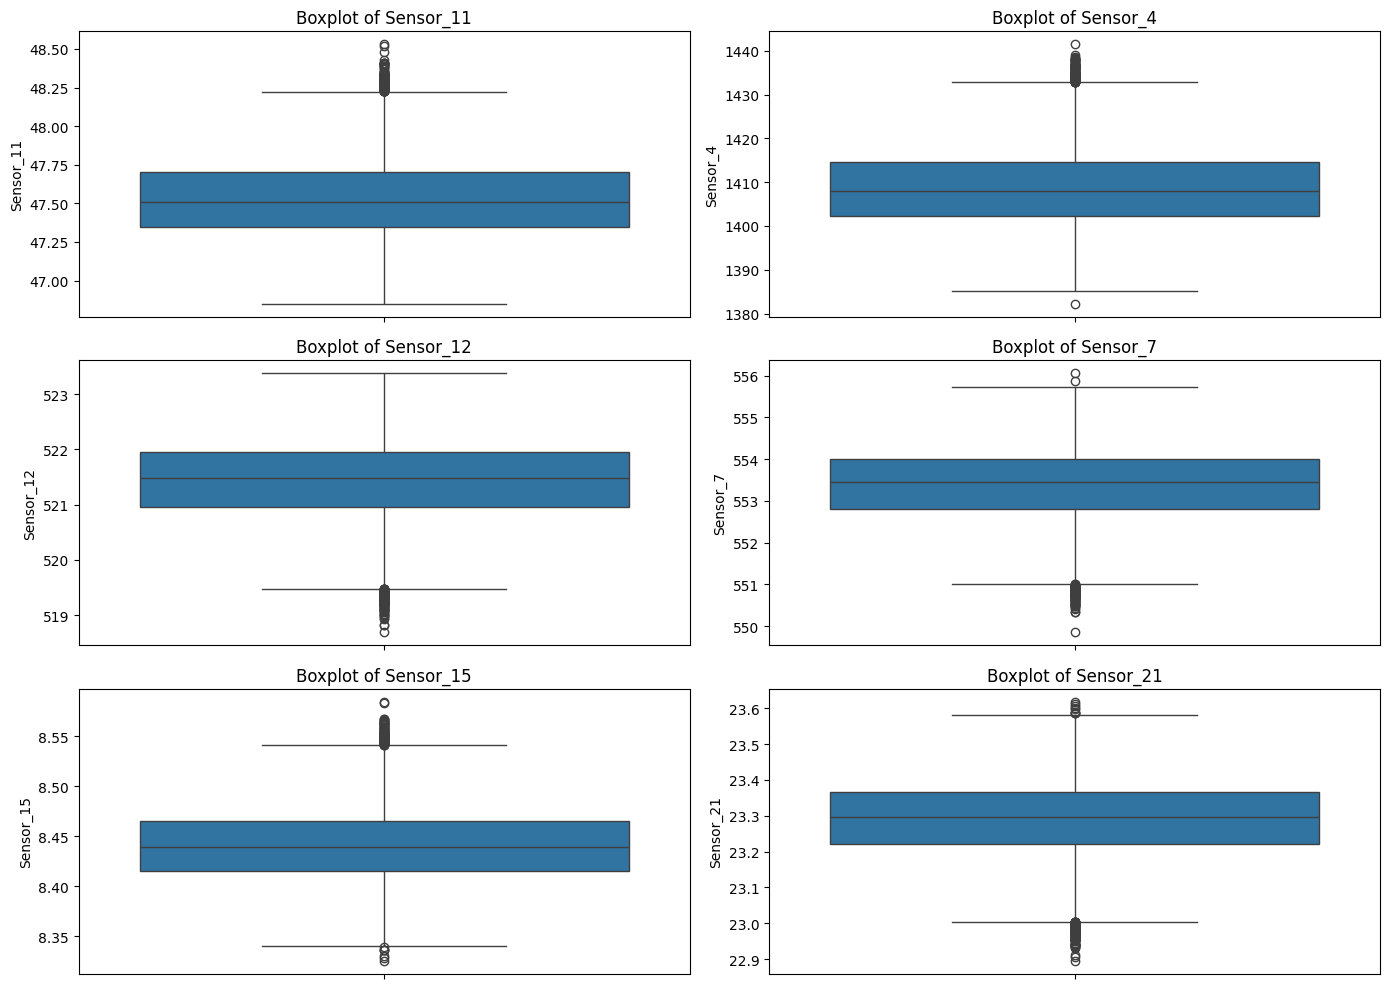

In [36]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 10)
)

axes = axes.flatten()

for ax, sensor in zip(axes, top_sensors):
    sns.boxplot(
        data=train_df,
        y=sensor,
        ax=ax
    )
    
    ax.set_title(f"Boxplot of {sensor}")
    ax.set_ylabel(sensor)

plt.tight_layout()
plt.show()

In [ ]:
# 28 — Calculate Remaining Useful Life (RUL)
# Purpose: Generate the RUL target for every training
#          observation based on the engine's last cycle

In [37]:
max_cycle_per_engine = train_df.groupby("Engine_ID")["Cycle"].transform("max")

train_df["RUL"] = max_cycle_per_engine - train_df["Cycle"]

train_df.head(10)

,Engine_ID,Cycle,Setting_1,Setting_2,Setting_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,...,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669,186
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774,185
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106,184
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066,183
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694,182


In [ ]:
# 29 — Verify RUL Calculation for Engine 1
# Purpose: Verify that RUL decreases from the beginning
#          of the engine trajectory to zero at its final cycle

In [38]:
engine_1_rul = train_df[
    train_df["Engine_ID"] == 1
][["Engine_ID", "Cycle", "RUL"]]

display(engine_1_rul.head(5))
display(engine_1_rul.tail(5))

,Engine_ID,Cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


,Engine_ID,Cycle,RUL
187,1,188,4
188,1,189,3
189,1,190,2
190,1,191,1
191,1,192,0


In [ ]:
# 30 — Analyze RUL Distribution
# Purpose: Examine the distribution and statistical properties
#          of the generated RUL target

In [39]:
print("Minimum RUL:", train_df["RUL"].min())
print("Maximum RUL:", train_df["RUL"].max())
print("Mean RUL:", train_df["RUL"].mean())
print("Median RUL:", train_df["RUL"].median())

print("\nRUL Statistics:")
display(train_df["RUL"].describe())

Minimum RUL: 0
Maximum RUL: 361
Mean RUL: 107.80786195530997
Median RUL: 103.0

RUL Statistics:


count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64

In [ ]:
# 31 — Visualize RUL Distribution
# Purpose: Visualize how Remaining Useful Life values are
#          distributed across the training observations

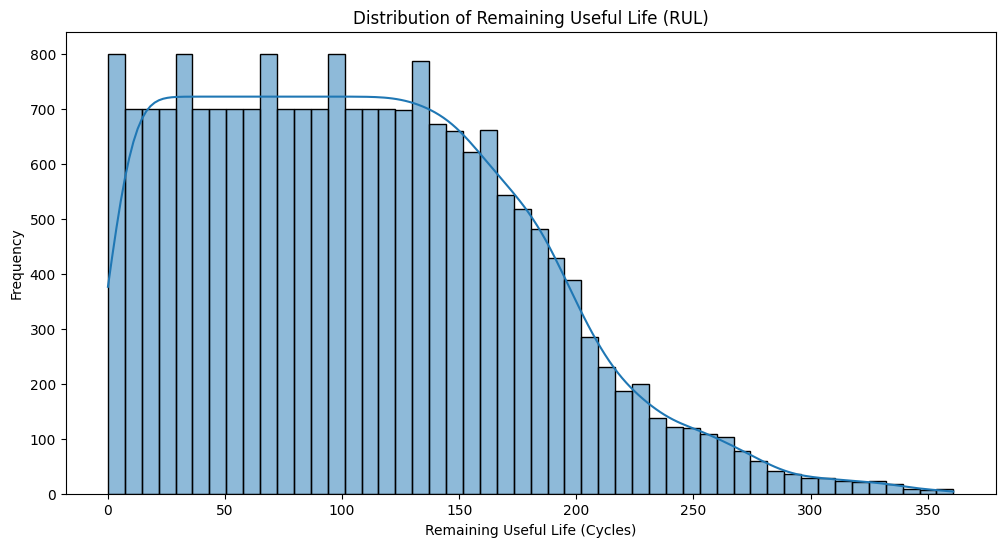

In [40]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=train_df,
    x="RUL",
    bins=50,
    kde=True
)

plt.title("Distribution of Remaining Useful Life (RUL)")
plt.xlabel("Remaining Useful Life (Cycles)")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# 32 — Visualize RUL Trajectories Across Engines
# Purpose: Visualize how RUL decreases as operating cycles
#          increase for multiple engine trajectories

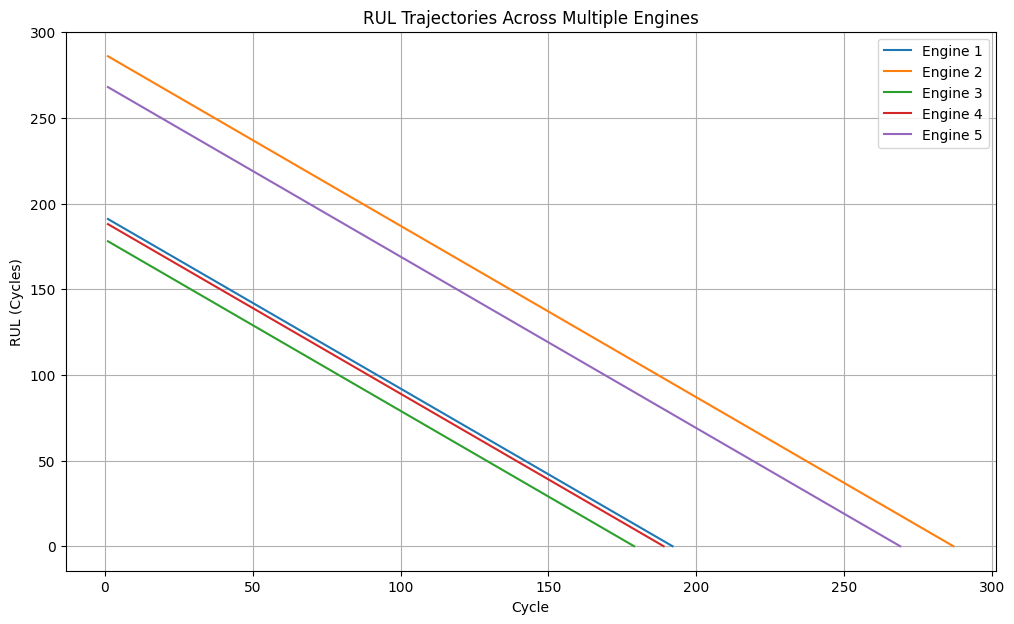

In [41]:
selected_engines = [1, 2, 3, 4, 5]

plt.figure(figsize=(12, 7))

for engine_id in selected_engines:
    
    engine_data = train_df[
        train_df["Engine_ID"] == engine_id
    ]
    
    plt.plot(
        engine_data["Cycle"],
        engine_data["RUL"],
        label=f"Engine {engine_id}"
    )

plt.title("RUL Trajectories Across Multiple Engines")
plt.xlabel("Cycle")
plt.ylabel("RUL (Cycles)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# 33 — Inspect Training Dataset After RUL Engineering
# Purpose: Confirm the dataset structure after adding the
#          supervised learning target

In [42]:
print("Training shape:", train_df.shape)

print("\nColumns:")
print(train_df.columns.tolist())

print("\nMissing values in RUL:", train_df["RUL"].isna().sum())

Training shape: (20631, 27)

Columns:
['Engine_ID', 'Cycle', 'Setting_1', 'Setting_2', 'Setting_3', 'Sensor_1', 'Sensor_2', 'Sensor_3', 'Sensor_4', 'Sensor_5', 'Sensor_6', 'Sensor_7', 'Sensor_8', 'Sensor_9', 'Sensor_10', 'Sensor_11', 'Sensor_12', 'Sensor_13', 'Sensor_14', 'Sensor_15', 'Sensor_16', 'Sensor_17', 'Sensor_18', 'Sensor_19', 'Sensor_20', 'Sensor_21', 'RUL']

Missing values in RUL: 0


In [ ]:
# 34 — Define Feature Groups
# Purpose: Separate engine identifiers, operating settings,
#          and sensor measurements for feature engineering

In [43]:
id_cols = [
    "Engine_ID",
    "Cycle"
]

setting_cols = [
    "Setting_1",
    "Setting_2",
    "Setting_3"
]

sensor_cols = [
    f"Sensor_{i}" for i in range(1, 22)
]

print("ID columns:", id_cols)
print("Setting columns:", setting_cols)
print("Number of sensors:", len(sensor_cols))

ID columns: ['Engine_ID', 'Cycle']
Setting columns: ['Setting_1', 'Setting_2', 'Setting_3']
Number of sensors: 21


In [ ]:
# 35 — Remove Constant Sensors
# Purpose: Remove sensors with zero variance because they
#          provide no useful variation for predictive models

In [44]:
constant_sensors = [
    sensor for sensor in sensor_cols
    if train_df[sensor].nunique() <= 1
]

train_df = train_df.drop(
    columns=constant_sensors
)

sensor_cols = [
    sensor for sensor in sensor_cols
    if sensor not in constant_sensors
]

print("Removed constant sensors:")
print(constant_sensors)

print("\nRemaining sensors:", len(sensor_cols))
print(sensor_cols)

Removed constant sensors:
['Sensor_1', 'Sensor_5', 'Sensor_10', 'Sensor_16', 'Sensor_18', 'Sensor_19']

Remaining sensors: 15
['Sensor_2', 'Sensor_3', 'Sensor_4', 'Sensor_6', 'Sensor_7', 'Sensor_8', 'Sensor_9', 'Sensor_11', 'Sensor_12', 'Sensor_13', 'Sensor_14', 'Sensor_15', 'Sensor_17', 'Sensor_20', 'Sensor_21']


In [ ]:
# 36 — Calculate Sensor Statistical Features
# Purpose: Calculate basic statistical characteristics of
#          sensor measurements for exploratory analysis

In [45]:
sensor_statistics = train_df[sensor_cols].agg(
    ["mean", "std", "min", "max"]
).T

display(sensor_statistics)

,mean,std,min,max
Sensor_2,642.680934,0.500053,641.2100,644.5300
Sensor_3,1590.523119,6.131150,1571.0400,1616.9100
Sensor_4,1408.933782,9.000605,1382.2500,1441.4900
Sensor_6,21.609803,0.001389,21.6000,21.6100
Sensor_7,553.367711,0.885092,549.8500,556.0600
Sensor_8,2388.096652,0.070985,2387.9000,2388.5600
Sensor_9,9065.242941,22.082880,9021.7300,9244.5900
Sensor_11,47.541168,0.267087,46.8500,48.5300
Sensor_12,521.413470,0.737553,518.6900,523.3800
Sensor_13,2388.096152,0.071919,2387.8800,2388.5600


In [ ]:
# 37 — Create Rolling Mean Features
# Purpose: Capture recent sensor behavior using rolling
#          averages over the previous operating cycles

In [46]:
rolling_window = 5

train_df = train_df.sort_values(
    ["Engine_ID", "Cycle"]
).copy()

for sensor in sensor_cols:
    
    train_df[f"{sensor}_RollingMean"] = (
        train_df
        .groupby("Engine_ID")[sensor]
        .transform(
            lambda x: x.rolling(
                window=rolling_window,
                min_periods=1
            ).mean()
        )
    )

In [ ]:
# 38 — Create Rolling Standard Deviation Features
# Purpose: Capture recent sensor variability and instability
#          over the previous operating cycles

In [47]:
for sensor in sensor_cols:
    
    train_df[f"{sensor}_RollingStd"] = (
        train_df
        .groupby("Engine_ID")[sensor]
        .transform(
            lambda x: x.rolling(
                window=rolling_window,
                min_periods=1
            ).std()
        )
    )

train_df = train_df.fillna(0)

In [ ]:
# 39 — Create Sensor Difference Features
# Purpose: Capture short-term changes in sensor measurements
#          from one operating cycle to the next

In [48]:
for sensor in sensor_cols:
    
    train_df[f"{sensor}_Diff"] = (
        train_df
        .groupby("Engine_ID")[sensor]
        .diff()
    )

train_df = train_df.fillna(0)

In [ ]:
# 40 — Create Sensor Trend Deviation Features
# Purpose: Measure how far the current sensor value is from
#          its recent rolling average

In [49]:
for sensor in sensor_cols:
    
    train_df[f"{sensor}_TrendDeviation"] = (
        train_df[sensor]
        - train_df[f"{sensor}_RollingMean"]
    )

In [ ]:
# 41 — Inspect Engineered Feature Dataset
# Purpose: Check the dataset dimensions and newly created
#          feature groups after feature engineering

In [50]:
print("New training shape:", train_df.shape)

print("\nOriginal sensor features:", len(sensor_cols))

print("\nExample engineered features:")

engineered_features = [
    col for col in train_df.columns
    if (
        "RollingMean" in col
        or "RollingStd" in col
        or "Diff" in col
        or "TrendDeviation" in col
    )
]

print(engineered_features[:20])

New training shape: (20631, 81)

Original sensor features: 15

Example engineered features:
['Sensor_2_RollingMean', 'Sensor_3_RollingMean', 'Sensor_4_RollingMean', 'Sensor_6_RollingMean', 'Sensor_7_RollingMean', 'Sensor_8_RollingMean', 'Sensor_9_RollingMean', 'Sensor_11_RollingMean', 'Sensor_12_RollingMean', 'Sensor_13_RollingMean', 'Sensor_14_RollingMean', 'Sensor_15_RollingMean', 'Sensor_17_RollingMean', 'Sensor_20_RollingMean', 'Sensor_21_RollingMean', 'Sensor_2_RollingStd', 'Sensor_3_RollingStd', 'Sensor_4_RollingStd', 'Sensor_6_RollingStd', 'Sensor_7_RollingStd']


In [ ]:
# 42 — Define Modeling Features and Target
# Purpose: Separate the input features from the RUL target
#          before training the predictive maintenance models

In [51]:
target = "RUL"

exclude_cols = [
    "Engine_ID",
    "RUL"
]

feature_cols = [
    col for col in train_df.columns
    if col not in exclude_cols
]

X = train_df[feature_cols]
y = train_df[target]

print("Number of features:", len(feature_cols))
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Number of features: 79
Feature matrix shape: (20631, 79)
Target shape: (20631,)


In [ ]:
# 43 — Split Data by Engine
# Purpose: Split complete engine trajectories into training
#          and validation sets to prevent data leakage

In [52]:
from sklearn.model_selection import train_test_split

engine_ids = train_df["Engine_ID"].unique()

train_engines, val_engines = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

train_data = train_df[
    train_df["Engine_ID"].isin(train_engines)
].copy()

val_data = train_df[
    train_df["Engine_ID"].isin(val_engines)
].copy()

print("Training engines:", len(train_engines))
print("Validation engines:", len(val_engines))

print("\nTraining rows:", len(train_data))
print("Validation rows:", len(val_data))

Training engines: 80
Validation engines: 20

Training rows: 16561
Validation rows: 4070


In [ ]:
# 44 — Create Training and Validation Matrices
# Purpose: Build X and y datasets for model training and
#          validation using the engine-based split

In [53]:
X_train = train_data[feature_cols]
y_train = train_data[target]

X_val = val_data[feature_cols]
y_val = val_data[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (16561, 79)
y_train: (16561,)
X_val: (4070, 79)
y_val: (4070,)


In [ ]:
# 45 — Scale Numerical Features
# Purpose: Standardize feature values using statistics learned
#          only from the training engines

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)

Scaled training shape: (16561, 79)
Scaled validation shape: (4070, 79)


In [ ]:
# 46 — Train Linear Regression Baseline
# Purpose: Train a simple regression baseline for predicting
#          Remaining Useful Life (RUL)

In [55]:
from sklearn.linear_model import LinearRegression

baseline_model = LinearRegression()

baseline_model.fit(
    X_train_scaled,
    y_train
)

y_pred_baseline = baseline_model.predict(
    X_val_scaled
)

print("Baseline model training completed.")

Baseline model training completed.


In [ ]:
# 47 — Evaluate Linear Regression Baseline
# Purpose: Evaluate RUL prediction performance using MAE,
#          RMSE, and R² metrics

In [56]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(
    y_val,
    y_pred_baseline
)

rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred_baseline
    )
)

r2 = r2_score(
    y_val,
    y_pred_baseline
)

print("Linear Regression Baseline")
print("---------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression Baseline
---------------------------
MAE : 25.180942298788107
RMSE: 31.694542554287757
R²  : 0.7669364797125352


In [ ]:
# 48 — Train Random Forest Regressor
# Purpose: Train a non-linear ensemble model to predict
#          Remaining Useful Life (RUL)

In [57]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(
    X_val
)

print("Random Forest training completed.")

Random Forest training completed.


In [ ]:
# 49 — Evaluate Random Forest Regressor
# Purpose: Measure Random Forest RUL prediction performance
#          using MAE, RMSE, and R²

In [58]:
mae_rf = mean_absolute_error(
    y_val,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_val,
    y_pred_rf
)

print("Random Forest Regressor")
print("-----------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Regressor
-----------------------
MAE : 23.457996065559893
RMSE: 31.731088239481103
R²  : 0.7663986977521646


In [ ]:
# 50 — Install pip in the Active Python Environment
# Purpose: Add pip to the current .venv so packages such as
#          XGBoost can be installed correctly

In [59]:
import sys
import ensurepip

print("Python executable:")
print(sys.executable)

ensurepip.bootstrap(upgrade=True)

print("\npip installation completed.")

Python executable:
c:\Users\win 10-11\.venv\Scripts\python.exe

pip installation completed.


In [ ]:
# 51 — Install XGBoost in the Active Python Environment
# Purpose: Install XGBoost using the exact Python environment
#          currently running the notebook

In [60]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "xgboost"
])

print("XGBoost installation completed successfully.")

XGBoost installation completed successfully.


In [ ]:
# 52 — Verify XGBoost Installation
# Purpose: Confirm that XGBoost is available in the active
#          notebook environment

In [61]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [ ]:
# 53 — Train XGBoost RUL Regression Model
# Purpose: Train an XGBoost model to predict the Remaining
#          Useful Life (RUL) of each engine

In [62]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_val)

print("XGBoost training completed successfully.")

XGBoost training completed successfully.


In [ ]:
# 54 — Evaluate XGBoost Regression Model
# Purpose: Measure XGBoost performance using MAE, RMSE, and R²

In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_xgb = mean_absolute_error(y_val, y_pred_xgb)

rmse_xgb = np.sqrt(
    mean_squared_error(y_val, y_pred_xgb)
)

r2_xgb = r2_score(y_val, y_pred_xgb)

print("XGBoost Evaluation Results")
print("--------------------------")
print(f"MAE  : {mae_xgb:.4f}")
print(f"RMSE : {rmse_xgb:.4f}")
print(f"R²   : {r2_xgb:.4f}")

XGBoost Evaluation Results
--------------------------
MAE  : 24.2519
RMSE : 32.3899
R²   : 0.7566


In [ ]:
# 55 — Compare Regression Models
# Purpose: Compare Linear Regression, Random Forest, and
#          XGBoost using MAE, RMSE, and R²

In [64]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae,
        mae_rf,
        mae_xgb
    ],
    "RMSE": [
        rmse,
        rmse_rf,
        rmse_xgb
    ],
    "R2": [
        r2,
        r2_rf,
        r2_xgb
    ]
})

display(results.sort_values("MAE"))

,Model,MAE,RMSE,R2
1,Random Forest,23.457996,31.731088,0.766399
2,XGBoost,24.251862,32.389922,0.756597
0,Linear Regression,25.180942,31.694543,0.766936


In [ ]:
# 56 — Analyze Random Forest Feature Importance
# Purpose: Identify the most important sensor and engineered
#          features contributing to RUL prediction

In [65]:
feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance.head(20))

,Feature,Importance
0,Cycle,0.544152
21,Sensor_4_RollingMean,0.073921
30,Sensor_15_RollingMean,0.065724
26,Sensor_11_RollingMean,0.047308
25,Sensor_9_RollingMean,0.029092
29,Sensor_14_RollingMean,0.028220
27,Sensor_12_RollingMean,0.014392
23,Sensor_7_RollingMean,0.011860
24,Sensor_8_RollingMean,0.010502
33,Sensor_21_RollingMean,0.009416


In [ ]:
# 57 — Visualize Top 15 Feature Importances
# Purpose: Visualize the most influential features used by
#          the Random Forest RUL prediction model

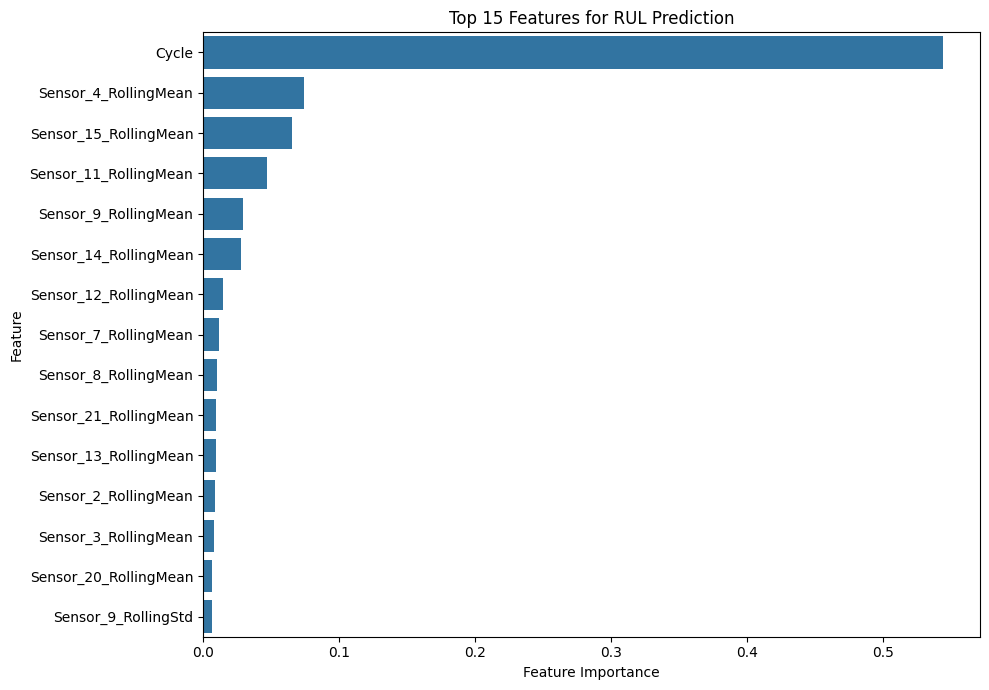

In [66]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features for RUL Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [ ]:
# 58 — Train Random Forest Without Cycle Feature
# Purpose: Test whether sensor-based features can predict RUL
#          without relying directly on engine operating age

In [67]:
feature_cols_no_cycle = [
    col for col in feature_cols
    if col != "Cycle"
]

X_train_no_cycle = train_data[feature_cols_no_cycle]
X_val_no_cycle = val_data[feature_cols_no_cycle]

rf_no_cycle = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_no_cycle.fit(X_train_no_cycle, y_train)

y_pred_rf_no_cycle = rf_no_cycle.predict(X_val_no_cycle)

print("Random Forest without Cycle trained successfully.")

Random Forest without Cycle trained successfully.


In [ ]:
# 59 — Evaluate Random Forest Without Cycle
# Purpose: Compare sensor-based RUL prediction against the
#          original Random Forest model

In [68]:
mae_rf_no_cycle = mean_absolute_error(
    y_val,
    y_pred_rf_no_cycle
)

rmse_rf_no_cycle = np.sqrt(
    mean_squared_error(y_val, y_pred_rf_no_cycle)
)

r2_rf_no_cycle = r2_score(
    y_val,
    y_pred_rf_no_cycle
)

print("Random Forest Without Cycle")
print("---------------------------")
print(f"MAE  : {mae_rf_no_cycle:.4f}")
print(f"RMSE : {rmse_rf_no_cycle:.4f}")
print(f"R²   : {r2_rf_no_cycle:.4f}")

Random Forest Without Cycle
---------------------------
MAE  : 24.4086
RMSE : 34.1815
R²   : 0.7289


In [ ]:
# 60 — Prepare Features for Deep Learning
# Purpose: Select the original sensor measurements and Cycle
#          for the Deep Learning models

In [69]:
dl_feature_cols = ["Cycle"] + sensor_cols

print("Number of Deep Learning features:", len(dl_feature_cols))
print("\nFeatures:")
print(dl_feature_cols)

Number of Deep Learning features: 16

Features:
['Cycle', 'Sensor_2', 'Sensor_3', 'Sensor_4', 'Sensor_6', 'Sensor_7', 'Sensor_8', 'Sensor_9', 'Sensor_11', 'Sensor_12', 'Sensor_13', 'Sensor_14', 'Sensor_15', 'Sensor_17', 'Sensor_20', 'Sensor_21']


In [ ]:
# 61 — Prepare Deep Learning Train and Validation Data
# Purpose: Create feature matrices using the engine-level
#          training and validation split

In [70]:
X_dl_train = train_data[dl_feature_cols].copy()
y_dl_train = train_data["RUL"].copy()

X_dl_val = val_data[dl_feature_cols].copy()
y_dl_val = val_data["RUL"].copy()

print("Training data shape:", X_dl_train.shape)
print("Validation data shape:", X_dl_val.shape)

Training data shape: (16561, 16)
Validation data shape: (4070, 16)


In [ ]:
# 62 — Scale Deep Learning Features
# Purpose: Standardize sensor and Cycle features using only
#          the training data to prevent data leakage

In [71]:
from sklearn.preprocessing import StandardScaler

dl_scaler = StandardScaler()

X_dl_train_scaled = dl_scaler.fit_transform(X_dl_train)
X_dl_val_scaled = dl_scaler.transform(X_dl_val)

print("Deep Learning feature scaling completed.")

Deep Learning feature scaling completed.


In [ ]:
# 63 — Define Time-Series Sequence Window
# Purpose: Define the number of consecutive engine cycles
#          used as input for the Deep Learning models

In [72]:
sequence_length = 30

print("Sequence length:", sequence_length)

Sequence length: 30


In [ ]:
# 64 — Create Training Time-Series Sequences
# Purpose: Convert training engine trajectories into
#          fixed-length sequences for Deep Learning

In [73]:
def create_sequences(data, feature_cols, target_col, sequence_length):
    
    X_sequences = []
    y_sequences = []
    
    for engine_id in data["Engine_ID"].unique():
        
        engine_data = data[
            data["Engine_ID"] == engine_id
        ].sort_values("Cycle")
        
        features = engine_data[feature_cols].values
        target_values = engine_data[target_col].values
        
        for i in range(len(engine_data) - sequence_length + 1):
            
            X_sequences.append(
                features[i:i + sequence_length]
            )
            
            y_sequences.append(
                target_values[i + sequence_length - 1]
            )
    
    return np.array(X_sequences), np.array(y_sequences)


X_seq_train, y_seq_train = create_sequences(
    train_data,
    dl_feature_cols,
    "RUL",
    sequence_length
)

print("Training sequences shape:", X_seq_train.shape)
print("Training targets shape:", y_seq_train.shape)

Training sequences shape: (14241, 30, 16)
Training targets shape: (14241,)


In [ ]:
# 65 — Create Validation Time-Series Sequences
# Purpose: Convert validation engine trajectories into
#          fixed-length sequences for model evaluation

In [74]:
X_seq_val, y_seq_val = create_sequences(
    val_data,
    dl_feature_cols,
    "RUL",
    sequence_length
)

print("Validation sequences shape:", X_seq_val.shape)
print("Validation targets shape:", y_seq_val.shape)

Validation sequences shape: (3490, 30, 16)
Validation targets shape: (3490,)


In [ ]:
# 66 — Verify Time-Series Sequence Structure
# Purpose: Confirm that each sequence contains consecutive
#          cycles from the same engine

In [75]:
sample_engine = train_data["Engine_ID"].iloc[0]

sample_engine_data = train_data[
    train_data["Engine_ID"] == sample_engine
].sort_values("Cycle")

print("Sample Engine ID:", sample_engine)
print(
    "Available cycles:",
    len(sample_engine_data)
)

print(
    "First sequence cycles:",
    sample_engine_data["Cycle"].iloc[:sequence_length].values
)

Sample Engine ID: 2
Available cycles: 287
First sequence cycles: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30]


In [ ]:
# 67A — Install TensorFlow in the Active Python Environment
# Purpose: Install TensorFlow into the exact .venv used
#          by the current notebook

In [76]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "tensorflow"
])

print("TensorFlow installation completed successfully.")

TensorFlow installation completed successfully.


In [ ]:
# 67B — Verify TensorFlow Installation
# Purpose: Confirm that TensorFlow is available in the
#          active notebook environment

In [77]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [ ]:
# 68 — Build DNN RUL Regression Model
# Purpose: Build a Deep Neural Network baseline for
#          Remaining Useful Life prediction

In [78]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout

dnn_model = Sequential([
    Input(shape=(sequence_length, len(dl_feature_cols))),
    
    Flatten(),
    
    Dense(128, activation="relu"),
    Dropout(0.2),
    
    Dense(64, activation="relu"),
    Dropout(0.2),
    
    Dense(32, activation="relu"),
    
    Dense(1, activation="linear")
])

dnn_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

dnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 480)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        61,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,937 (281.00 KB)

 Trainable params: 71,937 (281.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 69 — Train DNN RUL Regression Model
# Purpose: Train the DNN using the training sequences and
#          validate its performance on unseen engines

In [79]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_dnn = dnn_model.fit(
    X_seq_train,
    y_seq_train,
    validation_data=(X_seq_val, y_seq_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

print("DNN training completed.")

Epoch 1/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1378940.1250 - mae: 589.0519 - val_loss: 13546.9102 - val_mae: 101.2986
Epoch 2/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 40535.8906 - mae: 154.5003 - val_loss: 5832.4517 - val_mae: 59.7965
Epoch 3/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16129.9443 - mae: 98.3316 - val_loss: 3507.1897 - val_mae: 47.7845
Epoch 4/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9569.5410 - mae: 76.3428 - val_loss: 3289.9785 - val_mae: 47.2000
Epoch 5/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6987.1323 - mae: 65.5241 - val_loss: 3319.8005 - val_mae: 46.5651
Epoch 6/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5705.9663 - mae: 59.8948 - val_loss: 3891.0918 - val_mae: 49.6088
Epoch 7/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5074.8940 - mae: 56.4571 - val_loss: 3396.6028 - val_mae: 46.9945
Epoch 8/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4607.6567 - mae: 53.7657 - val_loss: 4065

In [ ]:
# 70 — Evaluate DNN RUL Predictions
# Purpose: Evaluate the DNN using MAE, RMSE, and R²
#          for comparison with the ML models

In [80]:
y_pred_dnn = dnn_model.predict(X_seq_val).flatten()

mae_dnn = mean_absolute_error(
    y_seq_val,
    y_pred_dnn
)

rmse_dnn = np.sqrt(
    mean_squared_error(y_seq_val, y_pred_dnn)
)

r2_dnn = r2_score(
    y_seq_val,
    y_pred_dnn
)

print("DNN Evaluation Results")
print("----------------------")
print(f"MAE  : {mae_dnn:.4f}")
print(f"RMSE : {rmse_dnn:.4f}")
print(f"R²   : {r2_dnn:.4f}")

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 931us/step
DNN Evaluation Results
----------------------
MAE  : 32.3546
RMSE : 38.4267
R²   : 0.5648


In [ ]:
# 71 — Build LSTM RUL Regression Model
# Purpose: Build a Long Short-Term Memory network that learns
#          temporal patterns from consecutive engine cycles

In [81]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

lstm_model = Sequential([
    Input(shape=(sequence_length, len(dl_feature_cols))),
    
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    
    LSTM(32),
    Dropout(0.2),
    
    Dense(16, activation="relu"),
    
    Dense(1, activation="linear")
])

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,697 (131.63 KB)

 Trainable params: 33,697 (131.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 72 — Train LSTM RUL Regression Model
# Purpose: Train the LSTM on engine sequences and validate
#          its ability to predict Remaining Useful Life

In [82]:
early_stopping_lstm = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_seq_train,
    y_seq_train,
    validation_data=(X_seq_val, y_seq_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping_lstm],
    verbose=1
)

print("LSTM training completed.")

Epoch 1/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 9945.1602 - mae: 79.3775 - val_loss: 5305.6191 - val_mae: 57.1917
Epoch 2/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 4499.1177 - mae: 52.7448 - val_loss: 3393.6946 - val_mae: 48.7722
Epoch 3/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 4008.4385 - mae: 51.3500 - val_loss: 3395.9124 - val_mae: 48.8295
Epoch 4/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 4011.3374 - mae: 51.3091 - val_loss: 3399.4597 - val_mae: 48.8951
Epoch 5/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 4017.0386 - mae: 51.3426 - val_loss: 3394.0159 - val_mae: 48.7819
Epoch 6/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 4013.7883 - mae: 51.3376 - val_loss: 3396.9387 - val_mae: 48.8499
Epoch 7/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 3999.5945 - mae: 51.2717 - val_loss: 3397.6021 - val_mae: 48.8618
Epoch 8/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 4005.5122 - mae: 51.2428 - val_loss: 3398.

In [ ]:
# 73 — Evaluate LSTM RUL Predictions
# Purpose: Evaluate LSTM performance using MAE, RMSE, and R²
#          for comparison with ML and DNN models

In [83]:
y_pred_lstm = lstm_model.predict(X_seq_val).flatten()

mae_lstm = mean_absolute_error(
    y_seq_val,
    y_pred_lstm
)

rmse_lstm = np.sqrt(
    mean_squared_error(y_seq_val, y_pred_lstm)
)

r2_lstm = r2_score(
    y_seq_val,
    y_pred_lstm
)

print("LSTM Evaluation Results")
print("-----------------------")
print(f"MAE  : {mae_lstm:.4f}")
print(f"RMSE : {rmse_lstm:.4f}")
print(f"R²   : {r2_lstm:.4f}")

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
LSTM Evaluation Results
-----------------------
MAE  : 48.7722
RMSE : 58.2554
R²   : -0.0003


In [ ]:
# 63 — Prepare Scaled Data for Deep Learning Sequences


In [84]:
train_dl_scaled = train_data[["Engine_ID", "Cycle"]].copy()
train_dl_scaled[dl_feature_cols] = dl_scaler.transform(
    train_data[dl_feature_cols]
)
train_dl_scaled["RUL"] = train_data["RUL"].values

val_dl_scaled = val_data[["Engine_ID", "Cycle"]].copy()
val_dl_scaled[dl_feature_cols] = dl_scaler.transform(
    val_data[dl_feature_cols]
)
val_dl_scaled["RUL"] = val_data["RUL"].values

print("Scaled training data shape:", train_dl_scaled.shape)
print("Scaled validation data shape:", val_dl_scaled.shape)

Scaled training data shape: (16561, 18)
Scaled validation data shape: (4070, 18)


In [ ]:
# 64 — Create Scaled Training Sequences


In [85]:
X_seq_train_scaled, y_seq_train = create_sequences(
    train_dl_scaled,
    dl_feature_cols,
    "RUL",
    sequence_length
)

print("Scaled training sequences shape:", X_seq_train_scaled.shape)
print("Training targets shape:", y_seq_train.shape)

Scaled training sequences shape: (14241, 30, 16)
Training targets shape: (14241,)


In [ ]:
# 65 — Create Scaled Validation Sequences


In [86]:
X_seq_val_scaled, y_seq_val = create_sequences(
    val_dl_scaled,
    dl_feature_cols,
    "RUL",
    sequence_length
)

print("Scaled validation sequences shape:", X_seq_val_scaled.shape)
print("Validation targets shape:", y_seq_val.shape)

Scaled validation sequences shape: (3490, 30, 16)
Validation targets shape: (3490,)


In [ ]:
# 66 — Build DNN Model Using Scaled Sequences


In [87]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout

dnn_scaled_model = Sequential([
    Input(shape=(sequence_length, len(dl_feature_cols))),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1, activation="linear")
])

dnn_scaled_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

dnn_scaled_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 480)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        61,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,937 (281.00 KB)

 Trainable params: 71,937 (281.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 67 — Train DNN on Properly Scaled Sequences


In [88]:
early_stopping_dnn_scaled = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_dnn_scaled = dnn_scaled_model.fit(
    X_seq_train_scaled,
    y_seq_train,
    validation_data=(X_seq_val_scaled, y_seq_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping_dnn_scaled],
    verbose=1
)

print("Scaled DNN training completed.")

Epoch 1/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3397.7505 - mae: 41.9239 - val_loss: 977.1653 - val_mae: 23.8512
Epoch 2/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1541.0404 - mae: 27.4586 - val_loss: 817.1531 - val_mae: 20.7424
Epoch 3/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1328.4834 - mae: 25.1110 - val_loss: 841.9489 - val_mae: 21.4954
Epoch 4/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1239.1411 - mae: 23.8947 - val_loss: 828.1003 - val_mae: 20.6878
Epoch 5/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1165.9362 - mae: 22.9737 - val_loss: 705.6000 - val_mae: 18.9585
Epoch 6/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1100.4188 - mae: 22.3665 - val_loss: 695.4260 - val_mae: 18.7757
Epoch 7/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1113.7697 - mae: 22.4252 - val_loss: 796.1477 - val_mae: 20.7186
Epoch 8/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1041.4653 - mae: 21.5588 - val_loss: 680.5267 - val_mae: 

In [ ]:
# 68 — Evaluate Scaled DNN Performance


In [89]:
y_pred_dnn_scaled = dnn_scaled_model.predict(
    X_seq_val_scaled
).flatten()

mae_dnn_scaled = mean_absolute_error(
    y_seq_val,
    y_pred_dnn_scaled
)

rmse_dnn_scaled = np.sqrt(
    mean_squared_error(
        y_seq_val,
        y_pred_dnn_scaled
    )
)

r2_dnn_scaled = r2_score(
    y_seq_val,
    y_pred_dnn_scaled
)

print("Scaled DNN Evaluation Results")
print("-----------------------------")
print(f"MAE  : {mae_dnn_scaled:.4f}")
print(f"RMSE : {rmse_dnn_scaled:.4f}")
print(f"R²   : {r2_dnn_scaled:.4f}")

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Scaled DNN Evaluation Results
-----------------------------
MAE  : 18.7543
RMSE : 26.0869
R²   : 0.7994


In [ ]:
# 69 — Build LSTM Model Using Properly Scaled Sequences


In [90]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

lstm_scaled_model = Sequential([
    Input(shape=(sequence_length, len(dl_feature_cols))),

    LSTM(64, return_sequences=True),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(16, activation="relu"),
    Dense(1, activation="linear")
])

lstm_scaled_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_scaled_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,697 (131.63 KB)

 Trainable params: 33,697 (131.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 70 — Train LSTM on Properly Scaled Sequences


In [91]:
early_stopping_lstm_scaled = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_lstm_scaled = lstm_scaled_model.fit(
    X_seq_train_scaled,
    y_seq_train,
    validation_data=(X_seq_val_scaled, y_seq_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping_lstm_scaled],
    verbose=1
)

print("Scaled LSTM training completed.")

Epoch 1/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 10200.9053 - mae: 80.4587 - val_loss: 6510.0933 - val_mae: 61.4894
Epoch 2/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 4920.4043 - mae: 48.6666 - val_loss: 2207.2849 - val_mae: 31.9150
Epoch 3/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1986.3326 - mae: 28.2050 - val_loss: 926.7621 - val_mae: 20.5065
Epoch 4/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1175.5839 - mae: 21.6298 - val_loss: 771.9161 - val_mae: 19.6616
Epoch 5/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 981.7689 - mae: 19.9185 - val_loss: 625.5800 - val_mae: 18.1717
Epoch 6/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 844.1317 - mae: 18.6624 - val_loss: 761.9203 - val_mae: 19.4271
Epoch 7/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 774.0823 - mae: 17.7743 - val_loss: 841.5930 - val_mae: 20.8863
Epoch 8/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 701.2717 - mae: 17.0102 - val_loss: 881.7438 - va

In [ ]:
# 71 — Evaluate Scaled LSTM Performance


In [92]:
y_pred_lstm_scaled = lstm_scaled_model.predict(
    X_seq_val_scaled
).flatten()

mae_lstm_scaled = mean_absolute_error(
    y_seq_val,
    y_pred_lstm_scaled
)

rmse_lstm_scaled = np.sqrt(
    mean_squared_error(
        y_seq_val,
        y_pred_lstm_scaled
    )
)

r2_lstm_scaled = r2_score(
    y_seq_val,
    y_pred_lstm_scaled
)

print("Scaled LSTM Evaluation Results")
print("------------------------------")
print(f"MAE  : {mae_lstm_scaled:.4f}")
print(f"RMSE : {rmse_lstm_scaled:.4f}")
print(f"R²   : {r2_lstm_scaled:.4f}")

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Scaled LSTM Evaluation Results
------------------------------
MAE  : 18.1717
RMSE : 25.0116
R²   : 0.8156


In [ ]:
# 72 — Build GRU Model Using Properly Scaled Sequences


In [93]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout

gru_model = Sequential([
    Input(shape=(sequence_length, len(dl_feature_cols))),

    GRU(64, return_sequences=True),
    Dropout(0.2),

    GRU(32),
    Dropout(0.2),

    Dense(16, activation="relu"),
    Dense(1, activation="linear")
])

gru_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

gru_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 64)         │        15,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,697 (100.38 KB)

 Trainable params: 25,697 (100.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 73 — Train GRU on Properly Scaled Sequences


In [94]:
early_stopping_gru = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_gru = gru_model.fit(
    X_seq_train_scaled,
    y_seq_train,
    validation_data=(X_seq_val_scaled, y_seq_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping_gru],
    verbose=1
)

print("GRU training completed.")

Epoch 1/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 9133.8174 - mae: 75.4500 - val_loss: 4928.1025 - val_mae: 53.5624
Epoch 2/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 3759.7419 - mae: 43.7404 - val_loss: 1659.2775 - val_mae: 28.8164
Epoch 3/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1772.0449 - mae: 28.5061 - val_loss: 934.5041 - val_mae: 22.3465
Epoch 4/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 1337.9945 - mae: 24.5976 - val_loss: 729.0360 - val_mae: 20.1733
Epoch 5/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 1142.2928 - mae: 22.5992 - val_loss: 692.9392 - val_mae: 19.8067
Epoch 6/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 989.3565 - mae: 21.3300 - val_loss: 570.9818 - val_mae: 17.2837
Epoch 7/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 926.6624 - mae: 20.6145 - val_loss: 593.4736 - val_mae: 17.2315
Epoch 8/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 833.6926 - mae: 19.6429 - val_loss: 603.4846 - va

In [ ]:
# 74 — Evaluate GRU Performance


In [95]:
y_pred_gru = gru_model.predict(
    X_seq_val_scaled
).flatten()

mae_gru = mean_absolute_error(
    y_seq_val,
    y_pred_gru
)

rmse_gru = np.sqrt(
    mean_squared_error(
        y_seq_val,
        y_pred_gru
    )
)

r2_gru = r2_score(
    y_seq_val,
    y_pred_gru
)

print("GRU Evaluation Results")
print("----------------------")
print(f"MAE  : {mae_gru:.4f}")
print(f"RMSE : {rmse_gru:.4f}")
print(f"R²   : {r2_gru:.4f}")

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
GRU Evaluation Results
----------------------
MAE  : 17.2837
RMSE : 23.8952
R²   : 0.8317


In [ ]:
# 75 — Create Final RUL Model Comparison


In [96]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "DNN",
        "LSTM",
        "GRU"
    ],
    "MAE": [
        mae,
        mean_absolute_error(y_val, y_pred_rf),
        mean_absolute_error(y_val, y_pred_xgb),
        mae_dnn_scaled,
        mae_lstm_scaled,
        mae_gru
    ],
    "RMSE": [
        rmse,
        np.sqrt(mean_squared_error(y_val, y_pred_rf)),
        np.sqrt(mean_squared_error(y_val, y_pred_xgb)),
        rmse_dnn_scaled,
        rmse_lstm_scaled,
        rmse_gru
    ],
    "R2": [
        r2,
        r2_score(y_val, y_pred_rf),
        r2_score(y_val, y_pred_xgb),
        r2_dnn_scaled,
        r2_lstm_scaled,
        r2_gru
    ]
})

model_comparison = model_comparison.sort_values(
    "MAE",
    ascending=True
).reset_index(drop=True)

display(model_comparison)

,Model,MAE,RMSE,R2
0,GRU,17.283653,23.895226,0.831700
1,LSTM,18.171730,25.011595,0.815607
2,DNN,18.754347,26.086906,0.799411
3,Random Forest,23.457996,31.731088,0.766399
4,XGBoost,24.251862,32.389922,0.756597
5,Linear Regression,25.180942,31.694543,0.766936


In [ ]:
# 76 — Visualize RUL Prediction Performance Across Models


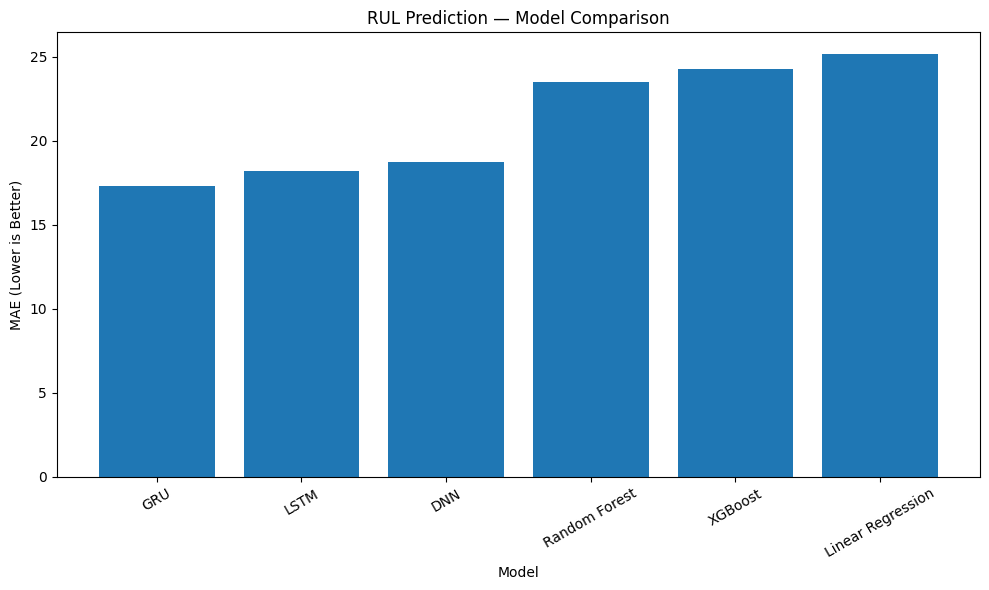

In [97]:
plt.figure(figsize=(10, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["MAE"]
)

plt.xlabel("Model")
plt.ylabel("MAE (Lower is Better)")
plt.title("RUL Prediction — Model Comparison")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
# 77 — Visualize RUL Prediction R² Across Models


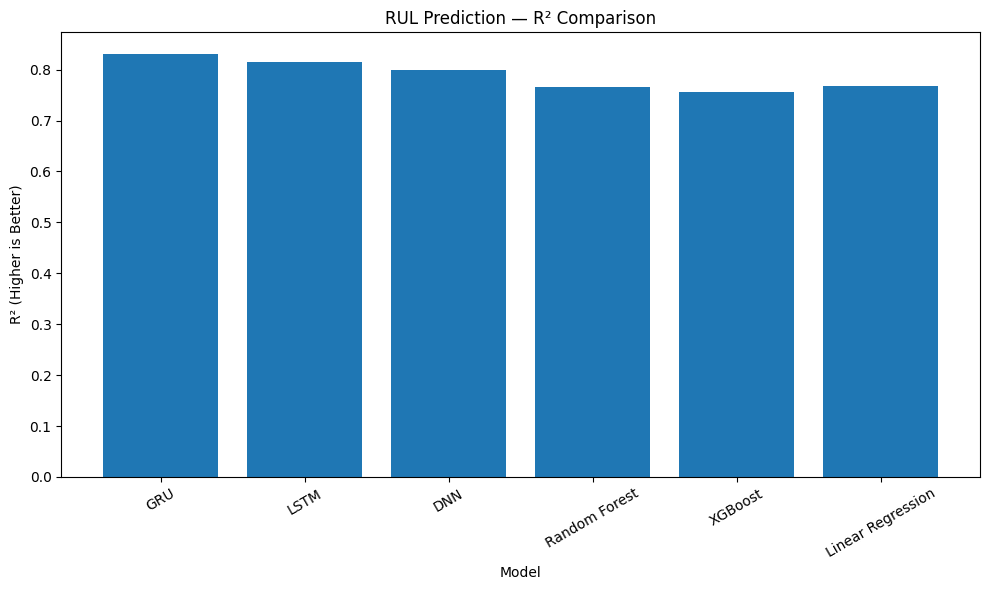

In [98]:
plt.figure(figsize=(10, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["R2"]
)

plt.xlabel("Model")
plt.ylabel("R² (Higher is Better)")
plt.title("RUL Prediction — R² Comparison")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
# 78 — Calculate Prediction Errors for DNN, LSTM, and GRU


In [99]:
error_analysis = pd.DataFrame({
    "Actual_RUL": y_seq_val,
    "DNN_Predicted": y_pred_dnn_scaled,
    "LSTM_Predicted": y_pred_lstm_scaled,
    "GRU_Predicted": y_pred_gru
})

error_analysis["DNN_Error"] = (
    error_analysis["DNN_Predicted"]
    - error_analysis["Actual_RUL"]
)

error_analysis["LSTM_Error"] = (
    error_analysis["LSTM_Predicted"]
    - error_analysis["Actual_RUL"]
)

error_analysis["GRU_Error"] = (
    error_analysis["GRU_Predicted"]
    - error_analysis["Actual_RUL"]
)

error_analysis["DNN_Absolute_Error"] = (
    error_analysis["DNN_Error"].abs()
)

error_analysis["LSTM_Absolute_Error"] = (
    error_analysis["LSTM_Error"].abs()
)

error_analysis["GRU_Absolute_Error"] = (
    error_analysis["GRU_Error"].abs()
)

display(error_analysis.head())

,Actual_RUL,DNN_Predicted,LSTM_Predicted,GRU_Predicted,DNN_Error,LSTM_Error,GRU_Error,DNN_Absolute_Error,LSTM_Absolute_Error,GRU_Absolute_Error
0,162,185.139420,165.494797,170.877502,23.139420,3.494797,8.877502,23.139420,3.494797,8.877502
1,161,186.959503,165.496613,171.031006,25.959503,4.496613,10.031006,25.959503,4.496613,10.031006
2,160,180.068481,165.500687,171.021332,20.068481,5.500687,11.021332,20.068481,5.500687,11.021332
3,159,192.296677,165.502853,170.845276,33.296677,6.502853,11.845276,33.296677,6.502853,11.845276
4,158,177.460846,165.483200,170.506927,19.460846,7.483200,12.506927,19.460846,7.483200,12.506927


In [ ]:
# 79 — Compare Actual and Predicted RUL


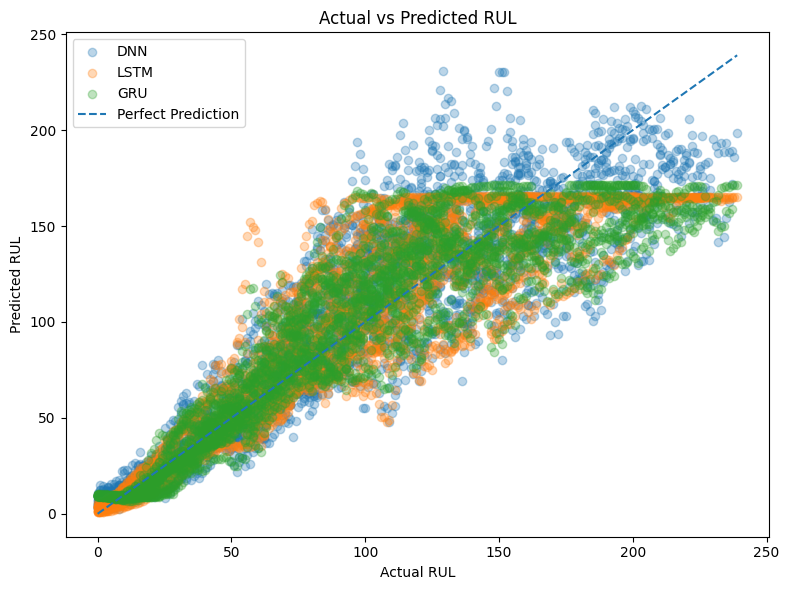

In [100]:
plt.figure(figsize=(8, 6))

plt.scatter(
    error_analysis["Actual_RUL"],
    error_analysis["DNN_Predicted"],
    alpha=0.3,
    label="DNN"
)

plt.scatter(
    error_analysis["Actual_RUL"],
    error_analysis["LSTM_Predicted"],
    alpha=0.3,
    label="LSTM"
)

plt.scatter(
    error_analysis["Actual_RUL"],
    error_analysis["GRU_Predicted"],
    alpha=0.3,
    label="GRU"
)

min_rul = error_analysis["Actual_RUL"].min()
max_rul = error_analysis["Actual_RUL"].max()

plt.plot(
    [min_rul, max_rul],
    [min_rul, max_rul],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 80 — Analyze Prediction Error Distribution


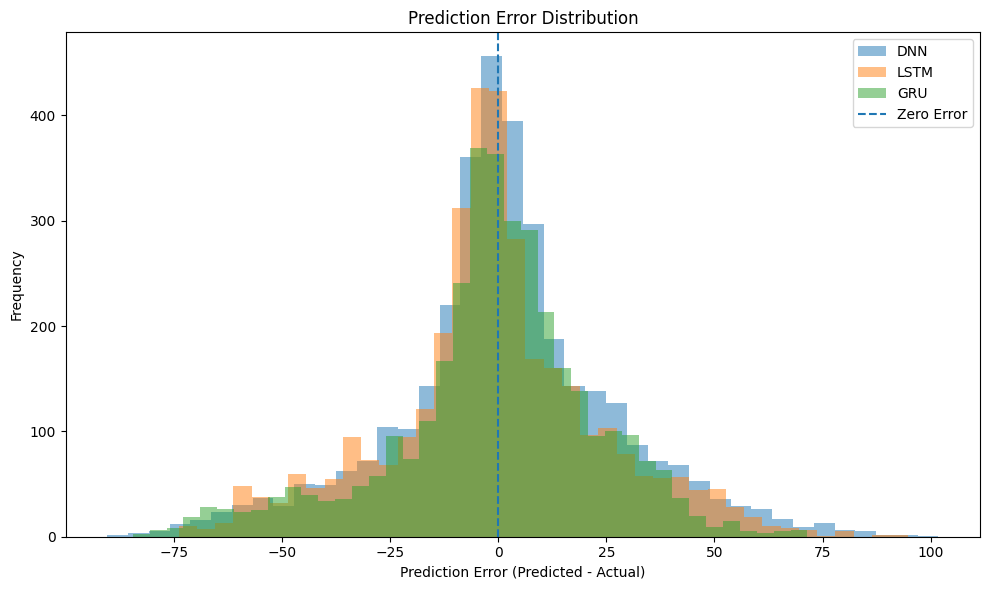

In [101]:
plt.figure(figsize=(10, 6))

plt.hist(
    error_analysis["DNN_Error"],
    bins=40,
    alpha=0.5,
    label="DNN"
)

plt.hist(
    error_analysis["LSTM_Error"],
    bins=40,
    alpha=0.5,
    label="LSTM"
)

plt.hist(
    error_analysis["GRU_Error"],
    bins=40,
    alpha=0.5,
    label="GRU"
)

plt.axvline(
    0,
    linestyle="--",
    label="Zero Error"
)

plt.xlabel("Prediction Error (Predicted - Actual)")
plt.ylabel("Frequency")
plt.title("Prediction Error Distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 81 — Analyze Model Error Across RUL Levels


In [102]:
error_analysis["RUL_Group"] = pd.cut(
    error_analysis["Actual_RUL"],
    bins=[-1, 20, 50, 100, 150, np.inf],
    labels=[
        "0-20",
        "21-50",
        "51-100",
        "101-150",
        "150+"
    ]
)

grouped_errors = error_analysis.groupby(
    "RUL_Group",
    observed=True
)[
    [
        "DNN_Absolute_Error",
        "LSTM_Absolute_Error",
        "GRU_Absolute_Error"
    ]
].mean()

display(grouped_errors)

,DNN_Absolute_Error,LSTM_Absolute_Error,GRU_Absolute_Error
RUL_Group,,,
0-20,4.172756,3.133151,4.425162
21-50,7.686105,7.008892,7.486890
51-100,18.217026,18.625901,15.895321
101-150,26.106880,23.559484,19.477950
150+,30.078710,30.947599,34.511933


In [ ]:
# 82 — Visualize Prediction Error Across RUL Ranges


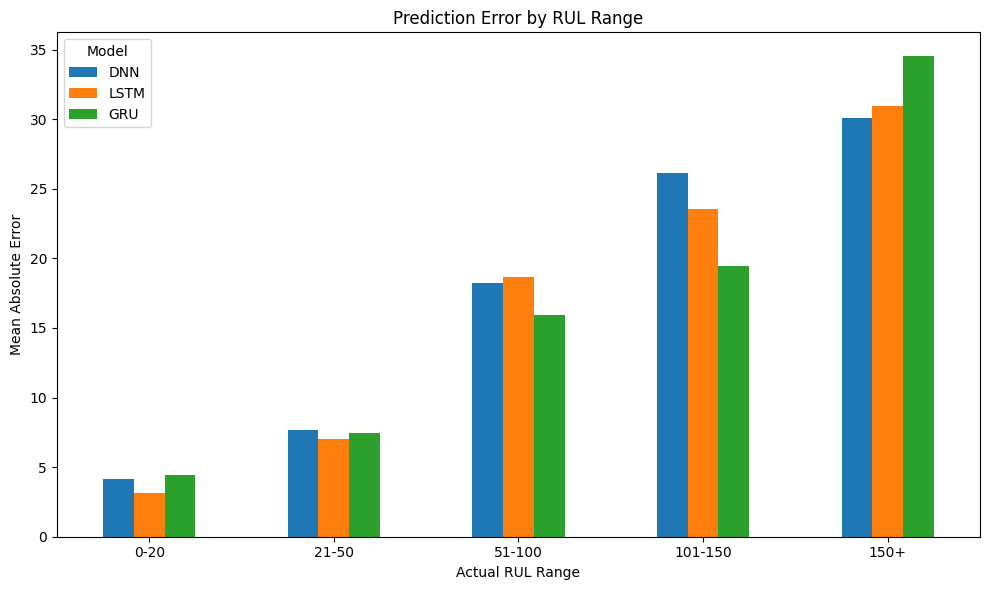

In [103]:
grouped_errors.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Actual RUL Range")
plt.ylabel("Mean Absolute Error")
plt.title("Prediction Error by RUL Range")
plt.xticks(rotation=0)
plt.legend(
    ["DNN", "LSTM", "GRU"],
    title="Model"
)

plt.tight_layout()
plt.show()

In [ ]:
# 83 — Identify the Largest GRU Prediction Errors


In [104]:
largest_gru_errors = error_analysis.sort_values(
    "GRU_Absolute_Error",
    ascending=False
).head(20)

display(
    largest_gru_errors[
        [
            "Actual_RUL",
            "DNN_Predicted",
            "LSTM_Predicted",
            "GRU_Predicted",
            "DNN_Absolute_Error",
            "LSTM_Absolute_Error",
            "GRU_Absolute_Error"
        ]
    ]
)

,Actual_RUL,DNN_Predicted,LSTM_Predicted,GRU_Predicted,DNN_Absolute_Error,LSTM_Absolute_Error,GRU_Absolute_Error
3151,232,141.621796,163.504913,147.534546,90.378204,68.495087,84.465454
3149,234,144.363892,163.897781,149.822113,89.636108,70.102219,84.177887
3150,233,150.735809,163.235031,149.701416,82.264191,69.764969,83.298584
3147,236,162.287704,164.078934,156.814529,73.712296,71.921066,79.185471
3152,231,154.188828,164.074936,151.974274,76.811172,66.925064,79.025726
3146,237,171.879227,164.542770,158.967438,65.120773,72.457230,78.032562
3153,230,153.114487,164.565475,152.435364,76.885513,65.434525,77.564636
3148,235,154.366013,164.296860,157.740860,80.633987,70.703140,77.259140
3169,214,151.720383,154.286545,136.929916,62.279617,59.713455,77.070084
3168,215,150.836792,157.559570,138.416992,64.163208,57.440430,76.583008


In [ ]:
# 84 — Calculate Prediction Bias


In [105]:
bias_comparison = pd.DataFrame({
    "Model": [
        "DNN",
        "LSTM",
        "GRU"
    ],
    "Mean_Error": [
        error_analysis["DNN_Error"].mean(),
        error_analysis["LSTM_Error"].mean(),
        error_analysis["GRU_Error"].mean()
    ],
    "Mean_Absolute_Error": [
        error_analysis["DNN_Absolute_Error"].mean(),
        error_analysis["LSTM_Absolute_Error"].mean(),
        error_analysis["GRU_Absolute_Error"].mean()
    ]
})

display(bias_comparison)

,Model,Mean_Error,Mean_Absolute_Error
0,DNN,1.350636,18.754347
1,LSTM,-1.013893,18.171730
2,GRU,-1.157203,17.283654


In [ ]:
# 85 — Define GRU Hyperparameter Configurations



In [106]:
gru_configs = [
    {
        "name": "GRU_64_32",
        "units_1": 64,
        "units_2": 32,
        "dropout": 0.2,
        "learning_rate": 0.001,
        "batch_size": 64
    },
    {
        "name": "GRU_128_64",
        "units_1": 128,
        "units_2": 64,
        "dropout": 0.2,
        "learning_rate": 0.001,
        "batch_size": 64
    },
    {
        "name": "GRU_64_32_Dropout03",
        "units_1": 64,
        "units_2": 32,
        "dropout": 0.3,
        "learning_rate": 0.001,
        "batch_size": 64
    },
    {
        "name": "GRU_128_64_Dropout03",
        "units_1": 128,
        "units_2": 64,
        "dropout": 0.3,
        "learning_rate": 0.001,
        "batch_size": 64
    }
]

print("Number of GRU configurations:", len(gru_configs))

Number of GRU configurations: 4


In [ ]:
# 86 — Create GRU Model Builder for Hyperparameter Tuning


In [107]:
from tensorflow.keras.optimizers import Adam

def build_gru_model(
    units_1,
    units_2,
    dropout,
    learning_rate
):
    model = Sequential([
        Input(
            shape=(
                sequence_length,
                len(dl_feature_cols)
            )
        ),

        GRU(
            units_1,
            return_sequences=True
        ),

        Dropout(dropout),

        GRU(units_2),

        Dropout(dropout),

        Dense(16, activation="relu"),

        Dense(1, activation="linear")
    ])

    optimizer = Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )

    return model

In [ ]:
# 87 — Run GRU Hyperparameter Experiments


In [108]:
tuning_results = []

for config in gru_configs:

    print(f"\nTraining: {config['name']}")

    model = build_gru_model(
        units_1=config["units_1"],
        units_2=config["units_2"],
        dropout=config["dropout"],
        learning_rate=config["learning_rate"]
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    )

    history = model.fit(
        X_seq_train_scaled,
        y_seq_train,
        validation_data=(
            X_seq_val_scaled,
            y_seq_val
        ),
        epochs=50,
        batch_size=config["batch_size"],
        callbacks=[early_stopping],
        verbose=0
    )

    predictions = model.predict(
        X_seq_val_scaled,
        verbose=0
    ).flatten()

    tuning_results.append({
        "Model": config["name"],
        "MAE": mean_absolute_error(
            y_seq_val,
            predictions
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_seq_val,
                predictions
            )
        ),
        "R2": r2_score(
            y_seq_val,
            predictions
        )
    })

    print(
        f"MAE: {tuning_results[-1]['MAE']:.4f} | "
        f"RMSE: {tuning_results[-1]['RMSE']:.4f} | "
        f"R²: {tuning_results[-1]['R2']:.4f}"
    )


Training: GRU_64_32
MAE: 17.6322 | RMSE: 24.6020 | R²: 0.8216

Training: GRU_128_64
MAE: 17.3765 | RMSE: 24.4190 | R²: 0.8242

Training: GRU_64_32_Dropout03
MAE: 17.9880 | RMSE: 24.4988 | R²: 0.8231

Training: GRU_128_64_Dropout03
MAE: 17.0575 | RMSE: 22.9998 | R²: 0.8441


In [ ]:
# 88 — Compare GRU Hyperparameter Tuning Results


In [109]:
tuning_results_df = pd.DataFrame(
    tuning_results
)

tuning_results_df = tuning_results_df.sort_values(
    "MAE",
    ascending=True
).reset_index(drop=True)

display(tuning_results_df)

,Model,MAE,RMSE,R2
0,GRU_128_64_Dropout03,17.057465,22.999838,0.844076
1,GRU_128_64,17.376543,24.418961,0.824241
2,GRU_64_32,17.632212,24.601972,0.821597
3,GRU_64_32_Dropout03,17.988018,24.498819,0.823090


In [ ]:
# 89 — Load Test RUL Labels and Prepare Test Data


In [110]:
test_rul = pd.read_csv(
    rul_path,
    sep=r"\s+",
    header=None,
    names=["RUL"]
)

print("Test RUL shape:", test_rul.shape)
print("\nFirst 5 RUL values:")
print(test_rul.head())

Test RUL shape: (100, 1)

First 5 RUL values:
   RUL
0  112
1   98
2   69
3   82
4   91


In [ ]:
# 90 — Calculate Maximum Observed Cycle for Each Test Engine


In [111]:
test_max_cycle = (
    test_df.groupby("Engine_ID")["Cycle"]
    .max()
)

test_max_cycle = test_max_cycle.reset_index()

test_max_cycle.columns = [
    "Engine_ID",
    "Max_Cycle"
]

display(test_max_cycle.head())

,Engine_ID,Max_Cycle
0,1,31
1,2,49
2,3,126
3,4,106
4,5,98


In [ ]:
# 91 — Calculate True RUL for Every Test Observation


In [112]:
test_df = test_df.copy()

test_df = test_df.merge(
    test_max_cycle,
    on="Engine_ID",
    how="left"
)

test_rul_values = test_rul["RUL"].values

test_rul_map = {
    engine_id: rul_value
    for engine_id, rul_value
    in zip(
        test_max_cycle["Engine_ID"],
        test_rul_values
    )
}

test_df["Final_RUL"] = test_df["Engine_ID"].map(
    test_rul_map
)

test_df["RUL"] = (
    test_df["Final_RUL"]
    + test_df["Max_Cycle"]
    - test_df["Cycle"]
)

print("Test dataset shape:", test_df.shape)

display(
    test_df[
        ["Engine_ID", "Cycle", "Final_RUL", "RUL"]
    ].head(10)
)

Test dataset shape: (13096, 29)


,Engine_ID,Cycle,Final_RUL,RUL
0,1,1,112,142
1,1,2,112,141
2,1,3,112,140
3,1,4,112,139
4,1,5,112,138
5,1,6,112,137
6,1,7,112,136
7,1,8,112,135
8,1,9,112,134
9,1,10,112,133


In [ ]:
# 92 — Verify Test Engine Cycles and RUL Labels


In [113]:
print("Test Engine 1:")
print(
    test_df[
        test_df["Engine_ID"] == 1
    ][
        ["Engine_ID", "Cycle", "Max_Cycle", "Final_RUL", "RUL"]
    ].tail()
)

print("\nRUL label for Engine 1:")
print(test_rul.iloc[0])

print("\nMaximum observed cycle for Engine 1:")
print(test_max_cycle.iloc[0])

Test Engine 1:
    Engine_ID  Cycle  Max_Cycle  Final_RUL  RUL
26          1     27         31        112  116
27          1     28         31        112  115
28          1     29         31        112  114
29          1     30         31        112  113
30          1     31         31        112  112

RUL label for Engine 1:
RUL    112
Name: 0, dtype: int64

Maximum observed cycle for Engine 1:
Engine_ID     1
Max_Cycle    31
Name: 0, dtype: int64


In [ ]:
# 93 — Remove Constant Sensors from Test Data


In [114]:
test_df = test_df.drop(
    columns=constant_sensors,
    errors="ignore"
)

print("Test shape after removing constant sensors:")
print(test_df.shape)

print("\nRemaining sensors:")
print(sensor_cols)

Test shape after removing constant sensors:
(13096, 23)

Remaining sensors:
['Sensor_2', 'Sensor_3', 'Sensor_4', 'Sensor_6', 'Sensor_7', 'Sensor_8', 'Sensor_9', 'Sensor_11', 'Sensor_12', 'Sensor_13', 'Sensor_14', 'Sensor_15', 'Sensor_17', 'Sensor_20', 'Sensor_21']


In [ ]:
# 94 — Prepare Test Features for Deep Learning


In [115]:
test_dl_data = test_df[
    ["Engine_ID"] + dl_feature_cols + ["RUL"]
].copy()

test_dl_data = test_dl_data.sort_values(
    ["Engine_ID", "Cycle"]
).reset_index(drop=True)

print("Test DL data shape:", test_dl_data.shape)
print("\nDeep Learning features:")
print(dl_feature_cols)

Test DL data shape: (13096, 18)

Deep Learning features:
['Cycle', 'Sensor_2', 'Sensor_3', 'Sensor_4', 'Sensor_6', 'Sensor_7', 'Sensor_8', 'Sensor_9', 'Sensor_11', 'Sensor_12', 'Sensor_13', 'Sensor_14', 'Sensor_15', 'Sensor_17', 'Sensor_20', 'Sensor_21']


In [ ]:
# 95 — Scale Test Features Using the Training Scaler


In [116]:
test_dl_scaled = test_dl_data[
    ["Engine_ID", "Cycle", "RUL"]
].copy()

test_dl_scaled[dl_feature_cols] = dl_scaler.transform(
    test_dl_data[dl_feature_cols]
)

print("Test feature scaling completed.")
print("Scaled test shape:", test_dl_scaled.shape)

Test feature scaling completed.
Scaled test shape: (13096, 18)


In [ ]:
# 96 — Create Scaled Test Sequences


In [117]:
X_seq_test_scaled, y_seq_test = create_sequences(
    test_dl_scaled,
    dl_feature_cols,
    "RUL",
    sequence_length
)

print("Test sequences shape:", X_seq_test_scaled.shape)
print("Test targets shape:", y_seq_test.shape)

Test sequences shape: (10196, 30, 16)
Test targets shape: (10196,)


In [ ]:
# 97 — Evaluate GRU on the Unseen Test Set


In [118]:
y_pred_gru_test = gru_model.predict(
    X_seq_test_scaled
).flatten()

mae_gru_test = mean_absolute_error(
    y_seq_test,
    y_pred_gru_test
)

rmse_gru_test = np.sqrt(
    mean_squared_error(
        y_seq_test,
        y_pred_gru_test
    )
)

r2_gru_test = r2_score(
    y_seq_test,
    y_pred_gru_test
)

print("GRU Test Set Evaluation")
print("------------------------")
print(f"MAE  : {mae_gru_test:.4f}")
print(f"RMSE : {rmse_gru_test:.4f}")
print(f"R²   : {r2_gru_test:.4f}")

319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
GRU Test Set Evaluation
------------------------
MAE  : 27.6469
RMSE : 38.0079
R²   : 0.5152


In [ ]:
#98 — Analyze GRU Test Errors by RUL Range

In [119]:
test_error_analysis = pd.DataFrame({
    "Actual_RUL": y_seq_test,
    "Predicted_RUL": y_pred_gru_test
})

test_error_analysis["Error"] = (
    test_error_analysis["Predicted_RUL"]
    - test_error_analysis["Actual_RUL"]
)

test_error_analysis["Absolute_Error"] = (
    test_error_analysis["Error"].abs()
)

test_error_analysis["RUL_Group"] = pd.cut(
    test_error_analysis["Actual_RUL"],
    bins=[-1, 20, 50, 100, 150, np.inf],
    labels=["0-20", "21-50", "51-100", "101-150", "150+"]
)

test_grouped_errors = test_error_analysis.groupby(
    "RUL_Group",
    observed=True
)["Absolute_Error"].mean()

display(test_grouped_errors)

RUL_Group
0-20        4.203650
21-50       8.467025
51-100     22.443090
101-150    22.167356
150+       43.246589
Name: Absolute_Error, dtype: float64

In [ ]:
# 99 — Analyze RUL Distribution Before Clipping

In [120]:
print("RUL Statistics")
print("----------------")
print(f"Minimum RUL : {train_df['RUL'].min():.2f}")
print(f"Maximum RUL : {train_df['RUL'].max():.2f}")
print(f"Mean RUL    : {train_df['RUL'].mean():.2f}")
print(f"Median RUL  : {train_df['RUL'].median():.2f}")

print("\nRUL Percentiles")
print("----------------")
print(train_df["RUL"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99]
))

RUL Statistics
----------------
Minimum RUL : 0.00
Maximum RUL : 361.00
Mean RUL    : 107.81
Median RUL  : 103.00

RUL Percentiles
----------------
0.50    103.0
0.75    155.0
0.90    198.0
0.95    229.0
0.99    287.0
Name: RUL, dtype: float64


In [ ]:
# 100 — Create Clipped RUL Targets for Validation Experiment

In [121]:
rul_caps = [100, 125, 150, 200]

clipped_results = []

for cap in rul_caps:
    y_train_clipped = np.minimum(y_seq_train, cap)
    y_val_clipped = np.minimum(y_seq_val, cap)

    print(f"RUL Cap: {cap}")
    print(f"Original train max RUL: {y_seq_train.max():.0f}")
    print(f"Clipped train max RUL: {y_train_clipped.max():.0f}")
    print(f"Original validation max RUL: {y_seq_val.max():.0f}")
    print(f"Clipped validation max RUL: {y_val_clipped.max():.0f}")
    print("-" * 40)

RUL Cap: 100
Original train max RUL: 332
Clipped train max RUL: 100
Original validation max RUL: 239
Clipped validation max RUL: 100
----------------------------------------
RUL Cap: 125
Original train max RUL: 332
Clipped train max RUL: 125
Original validation max RUL: 239
Clipped validation max RUL: 125
----------------------------------------
RUL Cap: 150
Original train max RUL: 332
Clipped train max RUL: 150
Original validation max RUL: 239
Clipped validation max RUL: 150
----------------------------------------
RUL Cap: 200
Original train max RUL: 332
Clipped train max RUL: 200
Original validation max RUL: 239
Clipped validation max RUL: 200
----------------------------------------


In [ ]:
#101 — Train and Compare GRU Models with Different RUL Caps

In [122]:
from tensorflow.keras.callbacks import EarlyStopping

cap_results = []

for cap in [100, 125, 150, 200]:

    print(f"\nTraining GRU with RUL Cap = {cap}")
    print("-" * 45)

    # Clip training and validation targets
    y_train_cap = np.minimum(y_seq_train, cap)
    y_val_cap = np.minimum(y_seq_val, cap)

    # Build a fresh GRU model
    cap_model = build_gru_model(
        units_1=64,
        units_2=32,
        dropout=0.2,
        learning_rate=0.001
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    cap_model.fit(
        X_seq_train_scaled,
        y_train_cap,
        validation_data=(X_seq_val_scaled, y_val_cap),
        epochs=100,
        batch_size=64,
        callbacks=[early_stopping],
        verbose=0
    )

    # Predict validation RUL
    y_pred_cap = cap_model.predict(
        X_seq_val_scaled,
        verbose=0
    ).flatten()

    # Evaluation
    mae_cap = mean_absolute_error(
        y_val_cap,
        y_pred_cap
    )

    rmse_cap = np.sqrt(
        mean_squared_error(
            y_val_cap,
            y_pred_cap
        )
    )

    r2_cap = r2_score(
        y_val_cap,
        y_pred_cap
    )

    cap_results.append({
        "RUL_Cap": cap,
        "MAE": mae_cap,
        "RMSE": rmse_cap,
        "R2": r2_cap
    })

    print(f"MAE  : {mae_cap:.4f}")
    print(f"RMSE : {rmse_cap:.4f}")
    print(f"R²   : {r2_cap:.4f}")

cap_results_df = pd.DataFrame(cap_results)

print("\nRUL Cap Comparison")
print("------------------")

display(
    cap_results_df.sort_values(
        "MAE",
        ascending=True
    )
)


Training GRU with RUL Cap = 100
---------------------------------------------
MAE  : 4.7540
RMSE : 7.6114
R²   : 0.9474

Training GRU with RUL Cap = 125
---------------------------------------------
MAE  : 7.8651
RMSE : 11.3257
R²   : 0.9264

Training GRU with RUL Cap = 150
---------------------------------------------
MAE  : 12.2568
RMSE : 16.0902
R²   : 0.8905

Training GRU with RUL Cap = 200
---------------------------------------------
MAE  : 16.5229
RMSE : 22.1739
R²   : 0.8479

RUL Cap Comparison
------------------


,RUL_Cap,MAE,RMSE,R2
0,100,4.753980,7.611418,0.947403
1,125,7.865129,11.325697,0.926423
2,150,12.256760,16.090171,0.890465
3,200,16.522943,22.173931,0.847893


In [ ]:
102 — Attempt to Retrain Cap=100 GRU (Memory Error)

This training attempt was interrupted by a MemoryError due to RAM limitations. The model was successfully retrained afterward using memory cleanup and a smaller batch size.

In [130]:
best_rul_cap = 100

y_train_cap = np.minimum(
    y_seq_train,
    best_rul_cap
)

y_val_cap = np.minimum(
    y_seq_val,
    best_rul_cap
)

best_gru_cap_model = build_gru_model(
    units_1=64,
    units_2=32,
    dropout=0.2,
    learning_rate=0.001
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_best_gru_cap = best_gru_cap_model.fit(
    X_seq_train_scaled,
    y_train_cap,
    validation_data=(
        X_seq_val_scaled,
        y_val_cap
    ),
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

print("Best RUL-capped GRU training completed.")
print(f"Selected RUL Cap: {best_rul_cap}")

MemoryError: Unable to allocate 26.1 MiB for an array with shape (14241, 30, 16) and data type float32

In [ ]:
#103 — Check Available RUL-Cap Models

In [123]:
print("Available variables:")

for name in [
    "cap_model",
    "best_gru_cap_model"
]:
    print(
        f"{name}:",
        "Exists" if name in globals() else "Not found"
    )

Available variables:
cap_model: Exists
best_gru_cap_model: Not found


In [ ]:
#104 — Free Memory Before Training Best GRU

In [124]:
import gc
import tensorflow as tf

# Delete unnecessary large objects
for name in [
    "dnn_model",
    "lstm_model",
    "cap_model",
    "history_best_gru_cap"
]:
    if name in globals():
        del globals()[name]

gc.collect()
tf.keras.backend.clear_session()

print("Memory cleanup completed.")


Memory cleanup completed.


In [ ]:
#105 — Train Final Validation GRU with RUL Cap 100

In [125]:
best_rul_cap = 100

y_train_cap = np.minimum(
    y_seq_train,
    best_rul_cap
)

y_val_cap = np.minimum(
    y_seq_val,
    best_rul_cap
)

best_gru_cap_model = build_gru_model(
    units_1=64,
    units_2=32,
    dropout=0.2,
    learning_rate=0.001
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_best_gru_cap = best_gru_cap_model.fit(
    X_seq_train_scaled,
    y_train_cap,
    validation_data=(
        X_seq_val_scaled,
        y_val_cap
    ),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print("Cap=100 GRU training completed.")

Epoch 1/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 2523.5808 - mae: 42.3017 - val_loss: 646.1093 - val_mae: 22.1515
Epoch 2/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 519.1669 - mae: 17.2572 - val_loss: 254.7894 - val_mae: 11.5625
Epoch 3/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 362.3803 - mae: 13.9960 - val_loss: 315.6255 - val_mae: 12.2228
Epoch 4/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 274.2165 - mae: 12.5537 - val_loss: 152.4617 - val_mae: 8.7576
Epoch 5/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 234.2901 - mae: 11.5923 - val_loss: 125.3857 - val_mae: 7.9122
Epoch 6/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 204.1378 - mae: 10.8400 - val_loss: 115.8318 - val_mae: 7.9633
Epoch 7/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 194.0113 - mae: 10.5550 - val_loss: 100.7256 - val_mae: 7.1499
Epoch 8/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 176.0997 - mae: 10.1087 - val_loss: 100.2869 - val_mae: 7.4

In [ ]:
#106 — Evaluate Cap=100 GRU on Validation Set

In [126]:
y_pred_gru_cap_val = best_gru_cap_model.predict(
    X_seq_val_scaled,
    verbose=0
).flatten()

mae_gru_cap_val = mean_absolute_error(
    y_val_cap,
    y_pred_gru_cap_val
)

rmse_gru_cap_val = np.sqrt(
    mean_squared_error(
        y_val_cap,
        y_pred_gru_cap_val
    )
)

r2_gru_cap_val = r2_score(
    y_val_cap,
    y_pred_gru_cap_val
)

print("Cap=100 GRU Validation Evaluation")
print("----------------------------------")
print(f"MAE  : {mae_gru_cap_val:.4f}")
print(f"RMSE : {rmse_gru_cap_val:.4f}")
print(f"R²   : {r2_gru_cap_val:.4f}")

Cap=100 GRU Validation Evaluation
----------------------------------
MAE  : 5.0671
RMSE : 8.1932
R²   : 0.9391


In [ ]:
#107 — Evaluate Cap=100 GRU on Unseen Test Set

In [127]:
# Cap the test RUL using the same cap used during training
y_test_cap = np.minimum(
    y_seq_test,
    best_rul_cap
)

# Predict test RUL
y_pred_gru_cap_test = best_gru_cap_model.predict(
    X_seq_test_scaled,
    verbose=0
).flatten()

# Evaluate
mae_gru_cap_test = mean_absolute_error(
    y_test_cap,
    y_pred_gru_cap_test
)

rmse_gru_cap_test = np.sqrt(
    mean_squared_error(
        y_test_cap,
        y_pred_gru_cap_test
    )
)

r2_gru_cap_test = r2_score(
    y_test_cap,
    y_pred_gru_cap_test
)

print("Cap=100 GRU Test Set Evaluation")
print("--------------------------------")
print(f"MAE  : {mae_gru_cap_test:.4f}")
print(f"RMSE : {rmse_gru_cap_test:.4f}")
print(f"R²   : {r2_gru_cap_test:.4f}")

Cap=100 GRU Test Set Evaluation
--------------------------------
MAE  : 4.6295
RMSE : 8.1806
R²   : 0.8451


In [ ]:
#108 — Create Failure Risk Labels from Capped RUL

In [128]:
def assign_risk(rul):
    if rul <= 20:
        return "High Risk"
    elif rul <= 50:
        return "Medium Risk"
    else:
        return "Low Risk"


# Create risk labels for training and validation sequences
risk_train = np.array([
    assign_risk(rul)
    for rul in y_train_cap
])

risk_val = np.array([
    assign_risk(rul)
    for rul in y_val_cap
])

# Create risk labels for test sequences
risk_test = np.array([
    assign_risk(rul)
    for rul in y_test_cap
])

print("Failure Risk Labels Created")
print("---------------------------")
print("Training:", np.unique(risk_train, return_counts=True))
print("Validation:", np.unique(risk_val, return_counts=True))
print("Test:", np.unique(risk_test, return_counts=True))

Failure Risk Labels Created
---------------------------
Training: (array(['High Risk', 'Low Risk', 'Medium Risk'], dtype='<U11'), array([ 1680, 10161,  2400]))
Validation: (array(['High Risk', 'Low Risk', 'Medium Risk'], dtype='<U11'), array([ 420, 2470,  600]))
Test: (array(['High Risk', 'Low Risk', 'Medium Risk'], dtype='<U11'), array([ 123, 9310,  763]))


In [ ]:
#109 — Analyze Failure Risk Class Distribution

In [129]:
risk_distribution = pd.DataFrame({
    "Risk_Level": ["High Risk", "Medium Risk", "Low Risk"],
    "Training_Count": [
        np.sum(risk_train == "High Risk"),
        np.sum(risk_train == "Medium Risk"),
        np.sum(risk_train == "Low Risk")
    ],
    "Validation_Count": [
        np.sum(risk_val == "High Risk"),
        np.sum(risk_val == "Medium Risk"),
        np.sum(risk_val == "Low Risk")
    ],
    "Test_Count": [
        np.sum(risk_test == "High Risk"),
        np.sum(risk_test == "Medium Risk"),
        np.sum(risk_test == "Low Risk")
    ]
})

risk_distribution["Training_Percentage"] = (
    risk_distribution["Training_Count"]
    / len(risk_train) * 100
)

display(risk_distribution)

,Risk_Level,Training_Count,Validation_Count,Test_Count,Training_Percentage
0,High Risk,1680,420,123,11.796924
1,Medium Risk,2400,600,763,16.852749
2,Low Risk,10161,2470,9310,71.350327


In [ ]:
#110 — Encode Failure Risk Labels

In [130]:
risk_mapping = {
    "Low Risk": 0,
    "Medium Risk": 1,
    "High Risk": 2
}

y_risk_train = np.array([
    risk_mapping[risk]
    for risk in risk_train
])

y_risk_val = np.array([
    risk_mapping[risk]
    for risk in risk_val
])

y_risk_test = np.array([
    risk_mapping[risk]
    for risk in risk_test
])

print("Encoded Failure Risk Labels")
print("---------------------------")
print("Classes:")
print("0 = Low Risk")
print("1 = Medium Risk")
print("2 = High Risk")

print("\nTraining labels:")
print(np.bincount(y_risk_train))

print("\nValidation labels:")
print(np.bincount(y_risk_val))

print("\nTest labels:")
print(np.bincount(y_risk_test))

Encoded Failure Risk Labels
---------------------------
Classes:
0 = Low Risk
1 = Medium Risk
2 = High Risk

Training labels:
[10161  2400  1680]

Validation labels:
[2470  600  420]

Test labels:
[9310  763  123]


In [131]:
#111 — Calculate Class Weights for Failure Risk Classification

In [132]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_risk_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_risk_train
)

class_weight_dict = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights)
}

print("Class Weights")
print("-------------")

for cls, weight in class_weight_dict.items():
    if cls == 0:
        label = "Low Risk"
    elif cls == 1:
        label = "Medium Risk"
    else:
        label = "High Risk"

    print(f"{cls} ({label}): {weight:.4f}")

Class Weights
-------------
0 (Low Risk): 0.4672
1 (Medium Risk): 1.9779
2 (High Risk): 2.8256


In [ ]:
#112 — Build GRU Failure Risk Classification Model

In [133]:
from tensorflow.keras.layers import Input, GRU, Dropout, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

risk_gru_model = Sequential([
    Input(
        shape=(
            sequence_length,
            len(dl_feature_cols)
        )
    ),

    GRU(64, return_sequences=True),
    Dropout(0.2),

    GRU(32),
    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(
        3,
        activation="softmax"
    )
])

risk_gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

risk_gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 30, 64)         │        15,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,731 (100.51 KB)

 Trainable params: 25,731 (100.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#113 — Train GRU Failure Risk Classifier

In [134]:
from tensorflow.keras.callbacks import EarlyStopping

risk_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

risk_history = risk_gru_model.fit(
    X_seq_train_scaled,
    y_risk_train,
    validation_data=(
        X_seq_val_scaled,
        y_risk_val
    ),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[risk_early_stopping],
    verbose=1
)

Epoch 1/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8306 - loss: 0.4287 - val_accuracy: 0.8309 - val_loss: 0.3790
Epoch 2/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9037 - loss: 0.2517 - val_accuracy: 0.9203 - val_loss: 0.1788
Epoch 3/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9291 - loss: 0.1835 - val_accuracy: 0.9241 - val_loss: 0.1708
Epoch 4/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9392 - loss: 0.1535 - val_accuracy: 0.9235 - val_loss: 0.1895
Epoch 5/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9484 - loss: 0.1386 - val_accuracy: 0.9364 - val_loss: 0.1564
Epoch 6/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9506 - loss: 0.1292 - val_accuracy: 0.9195 - val_loss: 0.2156
Epoch 7/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9601 - loss: 0.1051 - val_accuracy: 0.9361 - val_loss: 0.1584
Epoch 8/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9645 - loss: 0.1031 - 

In [ ]:
#114 — Generate Failure Risk Predictions

In [135]:
risk_probabilities = risk_gru_model.predict(
    X_seq_val_scaled,
    verbose=0
)

risk_predictions = np.argmax(
    risk_probabilities,
    axis=1
)

print("Failure Risk predictions generated.")
print("Prediction shape:", risk_predictions.shape)
print("Probability shape:", risk_probabilities.shape)

Failure Risk predictions generated.
Prediction shape: (3490,)
Probability shape: (3490, 3)


In [ ]:
#115 — Evaluate Failure Risk Classifier

In [136]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

risk_accuracy = accuracy_score(
    y_risk_val,
    risk_predictions
)

print("Failure Risk Classification Accuracy")
print("-------------------------------------")
print(f"Accuracy: {risk_accuracy:.4f}")

print("\nClassification Report")
print("---------------------")

print(
    classification_report(
        y_risk_val,
        risk_predictions,
        target_names=[
            "Low Risk",
            "Medium Risk",
            "High Risk"
        ],
        digits=4
    )
)

Failure Risk Classification Accuracy
-------------------------------------
Accuracy: 0.9364

Classification Report
---------------------
              precision    recall  f1-score   support

    Low Risk     0.9804    0.9543    0.9672      2470
 Medium Risk     0.8019    0.8367    0.8189       600
   High Risk     0.8891    0.9738    0.9295       420

    accuracy                         0.9364      3490
   macro avg     0.8905    0.9216    0.9052      3490
weighted avg     0.9388    0.9364    0.9372      3490



In [ ]:
#116 — Generate Failure Risk Confusion Matrix

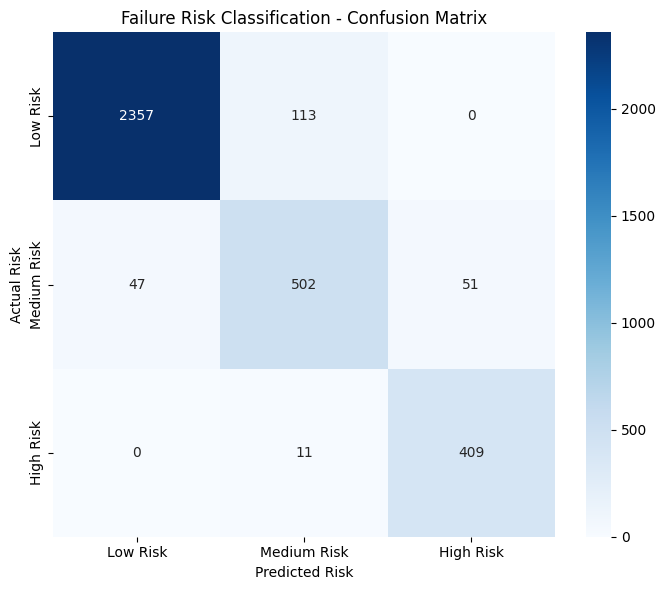

In [137]:
risk_cm = confusion_matrix(
    y_risk_val,
    risk_predictions
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    risk_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ],
    yticklabels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

plt.title("Failure Risk Classification - Confusion Matrix")
plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")
plt.tight_layout()
plt.show()

In [138]:
#117 — Calculate Risk Classification Metrics

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_risk_val,
    risk_predictions,
    labels=[0, 1, 2],
    zero_division=0
)

risk_metrics = pd.DataFrame({
    "Risk_Level": [
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ],
    "Precision": precision,
    "Recall": recall,
    "F1_Score": f1,
    "Support": support
})

display(risk_metrics)

In [ ]:
# 118 — Evaluate Failure Risk Classification on the Test Set


In [140]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Predict test risk classes
test_risk_probabilities = risk_gru_model.predict(
    X_seq_test_scaled,
    verbose=0
)

test_risk_predictions = np.argmax(
    test_risk_probabilities,
    axis=1
)

# Calculate accuracy
test_risk_accuracy = accuracy_score(
    y_risk_test,
    test_risk_predictions
)

print("Test Failure Risk Classification Accuracy")
print("------------------------------------------")
print(f"Accuracy: {test_risk_accuracy:.4f}")

print("\nTest Classification Report")
print("--------------------------")

print(
    classification_report(
        y_risk_test,
        test_risk_predictions,
        target_names=[
            "Low Risk",
            "Medium Risk",
            "High Risk"
        ],
        digits=4,
        zero_division=0
    )
)

Test Failure Risk Classification Accuracy
------------------------------------------
Accuracy: 0.9672

Test Classification Report
--------------------------
              precision    recall  f1-score   support

    Low Risk     0.9873    0.9823    0.9848      9310
 Medium Risk     0.7719    0.7982    0.7848       763
   High Risk     0.7500    0.8780    0.8090       123

    accuracy                         0.9672     10196
   macro avg     0.8364    0.8862    0.8595     10196
weighted avg     0.9683    0.9672    0.9677     10196



In [ ]:
# 119 — Prepare Sensor Features for Unsupervised Anomaly Detection


In [142]:
from sklearn.ensemble import IsolationForest

# Use sensor measurements only
# RUL and Risk labels are NOT used for training the anomaly detector
anomaly_features = sensor_cols

X_anomaly_train = train_data[
    anomaly_features
].copy()

X_anomaly_test = test_df[
    anomaly_features
].copy()

print("Anomaly detection features:", len(anomaly_features))
print("Training anomaly data:", X_anomaly_train.shape)
print("Test anomaly data:", X_anomaly_test.shape)

Anomaly detection features: 15
Training anomaly data: (16561, 15)
Test anomaly data: (13096, 15)


In [ ]:
# 120 — Standardize Sensor Features for Anomaly Detection


In [143]:
anomaly_scaler = StandardScaler()

X_anomaly_train_scaled = anomaly_scaler.fit_transform(
    X_anomaly_train
)

X_anomaly_test_scaled = anomaly_scaler.transform(
    X_anomaly_test
)

print("Anomaly detection features standardized successfully.")

Anomaly detection features standardized successfully.


In [ ]:
# 121 — Train Isolation Forest for Unsupervised Anomaly Detection


In [144]:
isolation_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

isolation_forest.fit(
    X_anomaly_train_scaled
)

print("Isolation Forest trained successfully.")

Isolation Forest trained successfully.


In [ ]:
# 122 — Generate Anomaly Predictions and Anomaly Scores

# Predictions:
#  1  = Normal
# -1  = Anomaly

In [145]:
train_anomaly_predictions = isolation_forest.predict(
    X_anomaly_train_scaled
)

test_anomaly_predictions = isolation_forest.predict(
    X_anomaly_test_scaled
)

# Higher score = more normal
# Lower score = more anomalous
train_anomaly_scores = isolation_forest.decision_function(
    X_anomaly_train_scaled
)

test_anomaly_scores = isolation_forest.decision_function(
    X_anomaly_test_scaled
)

print("Training anomalies:",
      (train_anomaly_predictions == -1).sum())

print("Test anomalies:",
      (test_anomaly_predictions == -1).sum())

print("Training anomaly rate:",
      (train_anomaly_predictions == -1).mean())

print("Test anomaly rate:",
      (test_anomaly_predictions == -1).mean())

Training anomalies: 828
Test anomalies: 121
Training anomaly rate: 0.0499969808586438
Test anomaly rate: 0.009239462431276727


In [ ]:
# 123 — Add Anomaly Detection Results to Test Data


In [146]:
test_df["Anomaly_Prediction"] = test_anomaly_predictions

test_df["Anomaly_Score"] = test_anomaly_scores

test_df["Anomaly_Status"] = np.where(
    test_df["Anomaly_Prediction"] == -1,
    "Anomaly",
    "Normal"
)

print(
    test_df[
        [
            "Engine_ID",
            "Cycle",
            "Anomaly_Score",
            "Anomaly_Status"
        ]
    ].head()
)

   Engine_ID  Cycle  Anomaly_Score Anomaly_Status
0          1      1       0.127613         Normal
1          1      2       0.100553         Normal
2          1      3       0.149070         Normal
3          1      4       0.131045         Normal
4          1      5       0.111433         Normal


In [ ]:
# 124 — Analyze Anomaly Frequency Across Engines


In [147]:
engine_anomaly_summary = (
    test_df
    .groupby("Engine_ID")
    .agg(
        Total_Cycles=("Cycle", "count"),
        Anomalous_Cycles=(
            "Anomaly_Prediction",
            lambda x: (x == -1).sum()
        ),
        Average_Anomaly_Score=(
            "Anomaly_Score",
            "mean"
        )
    )
    .reset_index()
)

engine_anomaly_summary["Anomaly_Rate"] = (
    engine_anomaly_summary["Anomalous_Cycles"]
    / engine_anomaly_summary["Total_Cycles"]
)

engine_anomaly_summary = (
    engine_anomaly_summary
    .sort_values(
        "Anomaly_Rate",
        ascending=False
    )
)

display(
    engine_anomaly_summary.head(10)
)

,Engine_ID,Total_Cycles,Anomalous_Cycles,Average_Anomaly_Score,Anomaly_Rate
77,78,72,10,0.051634,0.138889
64,65,71,9,0.062190,0.126761
98,99,97,8,0.075008,0.082474
53,54,121,9,0.078173,0.074380
51,52,189,14,0.082222,0.074074
23,24,186,10,0.083318,0.053763
31,32,145,6,0.082621,0.041379
33,34,203,8,0.103362,0.039409
58,59,94,3,0.096931,0.031915
38,39,37,1,0.114896,0.027027


In [ ]:
# 125 — Calculate Machine Health Score from Anomaly Behavior

# Convert anomaly score into a 0–100 health score.
# Higher anomaly score = healthier behavior.
# Lower anomaly score = more abnormal behavior.

In [149]:
score_min = test_df["Anomaly_Score"].min()
score_max = test_df["Anomaly_Score"].max()

test_df["Health_Score"] = (
    (test_df["Anomaly_Score"] - score_min)
    / (score_max - score_min)
) * 100

# Keep the score within 0–100
test_df["Health_Score"] = (
    test_df["Health_Score"]
    .clip(0, 100)
)

print("Machine Health Score created successfully.")
print(
    test_df[
        [
            "Engine_ID",
            "Cycle",
            "Anomaly_Score",
            "Health_Score",
            "Anomaly_Status"
        ]
    ].head()
)

Machine Health Score created successfully.
   Engine_ID  Cycle  Anomaly_Score  Health_Score Anomaly_Status
0          1      1       0.127613     77.907995         Normal
1          1      2       0.100553     67.482811         Normal
2          1      3       0.149070     86.174932         Normal
3          1      4       0.131045     79.230525         Normal
4          1      5       0.111433     71.674471         Normal


In [ ]:
# 126 — Calculate Overall Health Indicators for Each Engine


In [150]:
engine_health_summary = (
    test_df
    .groupby("Engine_ID")
    .agg(
        Average_Health_Score=(
            "Health_Score",
            "mean"
        ),
        Minimum_Health_Score=(
            "Health_Score",
            "min"
        ),
        Average_Anomaly_Score=(
            "Anomaly_Score",
            "mean"
        ),
        Anomalous_Cycles=(
            "Anomaly_Prediction",
            lambda x: (x == -1).sum()
        ),
        Total_Cycles=(
            "Cycle",
            "count"
        )
    )
    .reset_index()
)

engine_health_summary["Anomaly_Rate"] = (
    engine_health_summary["Anomalous_Cycles"]
    / engine_health_summary["Total_Cycles"]
)

engine_health_summary = (
    engine_health_summary
    .sort_values(
        "Average_Health_Score"
    )
)

display(
    engine_health_summary.head(10)
)

,Engine_ID,Average_Health_Score,Minimum_Health_Score,Average_Anomaly_Score,Anomalous_Cycles,Total_Cycles,Anomaly_Rate
77,78,48.635904,13.028796,0.051634,10,72,0.138889
64,65,52.702840,15.980215,0.062190,9,71,0.126761
98,99,57.641076,9.526725,0.075008,8,97,0.082474
53,54,58.860589,3.751800,0.078173,9,121,0.074380
51,52,60.420743,0.000000,0.082222,14,189,0.074074
31,32,60.574368,19.265927,0.082621,6,145,0.041379
23,24,60.842994,13.515103,0.083318,10,186,0.053763
22,23,65.172869,20.121110,0.094557,3,130,0.023077
61,62,65.849724,8.775460,0.096314,6,232,0.025862
95,96,65.905091,19.341321,0.096458,1,97,0.010309


In [ ]:
# 127 — Visualize Overall Machine Health Score Distribution


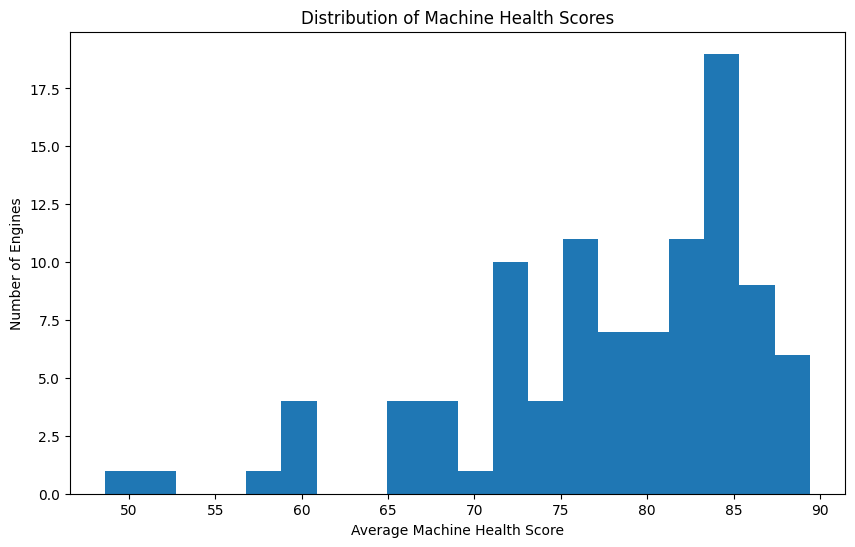

In [151]:
plt.figure(figsize=(10, 6))

plt.hist(
    engine_health_summary["Average_Health_Score"],
    bins=20
)

plt.xlabel("Average Machine Health Score")
plt.ylabel("Number of Engines")
plt.title("Distribution of Machine Health Scores")

plt.show()

In [ ]:
# 128 — Build Test Sequence Metadata


In [152]:
sequence_meta = []

for engine_id in test_dl_scaled["Engine_ID"].unique():

    engine_data = (
        test_dl_scaled[
            test_dl_scaled["Engine_ID"] == engine_id
        ]
        .sort_values("Cycle")
    )

    for i in range(len(engine_data) - sequence_length + 1):

        sequence_meta.append({
            "Engine_ID": engine_id,
            "End_Cycle": engine_data.iloc[
                i + sequence_length - 1
            ]["Cycle"]
        })

sequence_meta = pd.DataFrame(sequence_meta)

print("Sequence metadata shape:", sequence_meta.shape)
display(sequence_meta.head())

Sequence metadata shape: (10196, 2)


,Engine_ID,End_Cycle
0,1,-1.139867
1,1,-1.125507
2,2,-1.139867
3,2,-1.125507
4,2,-1.111147


In [ ]:
# 129 — Verify Prediction and Sequence Alignment


In [153]:
print("Number of test sequences:", len(sequence_meta))
print("Number of RUL predictions:", len(y_pred_gru_cap_test))
print("Number of risk predictions:", len(test_risk_predictions))

print("\nAlignment check:")

if (
    len(sequence_meta)
    == len(y_pred_gru_cap_test)
    == len(test_risk_predictions)
):
    print("✓ All predictions are correctly aligned.")
else:
    print("✗ Prediction alignment problem detected.")

Number of test sequences: 10196
Number of RUL predictions: 10196
Number of risk predictions: 10196

Alignment check:
✓ All predictions are correctly aligned.


In [ ]:
# 130 — Add RUL and Risk Predictions to Sequence Metadata


In [154]:
sequence_meta["Predicted_RUL"] = (
    y_pred_gru_cap_test
)

sequence_meta["Risk_Class"] = (
    test_risk_predictions
)

risk_label_mapping = {
    0: "Low Risk",
    1: "Medium Risk",
    2: "High Risk"
}

sequence_meta["Risk_Level"] = (
    sequence_meta["Risk_Class"]
    .map(risk_label_mapping)
)

display(sequence_meta.head())

,Engine_ID,End_Cycle,Predicted_RUL,Risk_Class,Risk_Level
0,1,-1.139867,99.483536,0,Low Risk
1,1,-1.125507,99.488708,0,Low Risk
2,2,-1.139867,99.434158,0,Low Risk
3,2,-1.125507,99.393379,0,Low Risk
4,2,-1.111147,99.138397,0,Low Risk


In [ ]:
# 131 — Extract Latest Prediction for Each Engine


In [155]:
latest_engine_predictions = (
    sequence_meta
    .sort_values(
        ["Engine_ID", "End_Cycle"]
    )
    .groupby("Engine_ID")
    .tail(1)
    .reset_index(drop=True)
)

display(
    latest_engine_predictions.head(10)
)

,Engine_ID,End_Cycle,Predicted_RUL,Risk_Class,Risk_Level
0,1,-1.125507,99.488708,0,Low Risk
1,2,-0.867027,99.206772,0,Low Risk
2,3,0.238695,46.610477,1,Medium Risk
3,4,-0.048506,77.040825,0,Low Risk
4,5,-0.163386,97.018295,0,Low Risk
5,6,-0.062866,96.647827,0,Low Risk
6,7,0.726936,97.376480,0,Low Risk
7,8,0.813096,95.299210,0,Low Risk
8,9,-0.780867,99.346382,0,Low Risk
9,10,1.186456,94.993019,0,Low Risk


In [ ]:
# 132 — Extract Latest Anomaly and Health Status


In [156]:
latest_cycle_status = (
    test_df
    .sort_values(
        ["Engine_ID", "Cycle"]
    )
    .groupby("Engine_ID")
    .tail(1)
    [
        [
            "Engine_ID",
            "Cycle",
            "Anomaly_Score",
            "Anomaly_Status",
            "Health_Score"
        ]
    ]
    .reset_index(drop=True)
)

display(
    latest_cycle_status.head(10)
)

,Engine_ID,Cycle,Anomaly_Score,Anomaly_Status,Health_Score
0,1,31,0.140145,Normal,82.736268
1,2,49,0.145045,Normal,84.624065
2,3,126,0.109757,Normal,71.028944
3,4,106,0.129602,Normal,78.674610
4,5,98,0.132218,Normal,79.682334
5,6,105,0.162736,Normal,91.439675
6,7,160,0.141661,Normal,83.320164
7,8,166,0.141674,Normal,83.325526
8,9,55,0.149113,Normal,86.191293
9,10,192,0.159137,Normal,90.053143


In [ ]:
# 133 — Build Final Engine Health Summary


In [157]:
final_engine_summary = (
    latest_engine_predictions
    .merge(
        latest_cycle_status,
        on="Engine_ID",
        how="left"
    )
    .merge(
        engine_health_summary[
            [
                "Engine_ID",
                "Anomaly_Rate",
                "Average_Health_Score"
            ]
        ],
        on="Engine_ID",
        how="left"
    )
)

final_engine_summary = (
    final_engine_summary
    .sort_values("Engine_ID")
    .reset_index(drop=True)
)

display(final_engine_summary.head(10))

,Engine_ID,End_Cycle,Predicted_RUL,Risk_Class,Risk_Level,Cycle,Anomaly_Score,Anomaly_Status,Health_Score,Anomaly_Rate,Average_Health_Score
0,1,-1.125507,99.488708,0,Low Risk,31,0.140145,Normal,82.736268,0.000000,78.553991
1,2,-0.867027,99.206772,0,Low Risk,49,0.145045,Normal,84.624065,0.000000,83.976529
2,3,0.238695,46.610477,1,Medium Risk,126,0.109757,Normal,71.028944,0.000000,84.418601
3,4,-0.048506,77.040825,0,Low Risk,106,0.129602,Normal,78.674610,0.000000,86.968322
4,5,-0.163386,97.018295,0,Low Risk,98,0.132218,Normal,79.682334,0.000000,86.882619
5,6,-0.062866,96.647827,0,Low Risk,105,0.162736,Normal,91.439675,0.000000,87.545376
6,7,0.726936,97.376480,0,Low Risk,160,0.141661,Normal,83.320164,0.006250,73.239251
7,8,0.813096,95.299210,0,Low Risk,166,0.141674,Normal,83.325526,0.000000,84.260025
8,9,-0.780867,99.346382,0,Low Risk,55,0.149113,Normal,86.191293,0.000000,85.683562
9,10,1.186456,94.993019,0,Low Risk,192,0.159137,Normal,90.053143,0.010417,75.852303


In [ ]:
# 134 — Check Final Dashboard Dataset


In [158]:
print("Final Engine Health Summary")
print("===========================")

print("Number of engines:", len(final_engine_summary))
print(
    "Number of columns:",
    len(final_engine_summary.columns)
)

print("\nColumns:")
print(
    final_engine_summary.columns.tolist()
)

print("\nMissing values:")
print(
    final_engine_summary.isnull().sum()
)

Final Engine Health Summary
Number of engines: 100
Number of columns: 11

Columns:
['Engine_ID', 'End_Cycle', 'Predicted_RUL', 'Risk_Class', 'Risk_Level', 'Cycle', 'Anomaly_Score', 'Anomaly_Status', 'Health_Score', 'Anomaly_Rate', 'Average_Health_Score']

Missing values:
Engine_ID               0
End_Cycle               0
Predicted_RUL           0
Risk_Class              0
Risk_Level              0
Cycle                   0
Anomaly_Score           0
Anomaly_Status          0
Health_Score            0
Anomaly_Rate            0
Average_Health_Score    0
dtype: int64


In [ ]:
# 135 — Analyze Final Engine Health Summary


In [159]:
print("Final Engine Health Summary")
print("===========================")

print(f"Total Engines: {len(final_engine_summary)}")

print("\nRisk Distribution:")
print(
    final_engine_summary["Risk_Level"]
    .value_counts()
)

print("\nAnomaly Status Distribution:")
print(
    final_engine_summary["Anomaly_Status"]
    .value_counts()
)

print("\nPredicted RUL Statistics:")
print(
    final_engine_summary["Predicted_RUL"]
    .describe()
)

Final Engine Health Summary
Total Engines: 100

Risk Distribution:
Risk_Level
Low Risk       66
Medium Risk    19
High Risk      15
Name: count, dtype: int64

Anomaly Status Distribution:
Anomaly_Status
Normal     97
Anomaly     3
Name: count, dtype: int64

Predicted RUL Statistics:
count    100.000000
mean      69.625587
std       34.054165
min        7.216363
25%       32.294040
50%       89.565357
75%       97.590189
max       99.606781
Name: Predicted_RUL, dtype: float64


In [ ]:
# 136 — Identify Engines Requiring Attention


In [160]:
attention_engines = (
    final_engine_summary[
        (
            final_engine_summary["Risk_Level"]
            == "High Risk"
        )
        |
        (
            final_engine_summary["Anomaly_Status"]
            == "Anomaly"
        )
    ]
    .sort_values(
        ["Risk_Class", "Predicted_RUL"],
        ascending=[False, True]
    )
)

print(
    "Engines requiring attention:",
    len(attention_engines)
)

display(
    attention_engines[
        [
            "Engine_ID",
            "End_Cycle",
            "Predicted_RUL",
            "Risk_Level",
            "Anomaly_Status",
            "Anomaly_Score",
            "Health_Score",
            "Anomaly_Rate"
        ]
    ].head(20)
)

Engines requiring attention: 16


,Engine_ID,End_Cycle,Predicted_RUL,Risk_Level,Anomaly_Status,Anomaly_Score,Health_Score,Anomaly_Rate
75,76,1.373137,7.216363,High Risk,Normal,0.038710,43.656804,0.009756
80,81,1.488017,7.607173,High Risk,Normal,0.031359,40.824749,0.004695
41,42,0.669496,7.919237,High Risk,Normal,0.006090,31.089521,0.006410
34,35,1.272617,8.316917,High Risk,Normal,0.022144,37.274675,0.005051
67,68,1.114656,8.450459,High Risk,Normal,0.052371,48.919871,0.000000
33,34,1.344417,8.477861,High Risk,Anomaly,-0.021865,20.319443,0.039409
30,31,1.243897,8.777111,High Risk,Normal,0.063622,53.254483,0.000000
81,82,0.755656,10.475395,High Risk,Normal,0.015388,34.671605,0.006173
55,56,0.382295,15.413122,High Risk,Normal,0.030328,40.427641,0.007353
65,66,0.540255,18.053257,High Risk,Normal,0.031685,40.950591,0.000000


In [ ]:
# 137 — Rank Engines by Health Indicators


In [161]:
engine_ranking = (
    final_engine_summary[
        [
            "Engine_ID",
            "Predicted_RUL",
            "Risk_Level",
            "Health_Score",
            "Average_Health_Score",
            "Anomaly_Rate",
            "Anomaly_Status"
        ]
    ]
    .sort_values(
        [
            "Health_Score",
            "Predicted_RUL"
        ],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)

display(
    engine_ranking.head(20)
)

,Engine_ID,Predicted_RUL,Risk_Level,Health_Score,Average_Health_Score,Anomaly_Rate,Anomaly_Status
0,34,8.477861,High Risk,20.319443,68.565196,0.039409,Anomaly
1,100,20.585274,High Risk,23.755887,72.306837,0.005051,Anomaly
2,65,99.206642,Low Risk,26.870655,52.702840,0.126761,Anomaly
3,42,7.919237,High Risk,31.089521,68.811493,0.006410,Normal
4,82,10.475395,High Risk,34.671605,81.510644,0.006173,Normal
5,20,19.469151,High Risk,35.420358,82.739322,0.000000,Normal
6,35,8.316917,High Risk,37.274675,79.077898,0.005051,Normal
7,56,15.413122,High Risk,40.427641,68.931163,0.007353,Normal
8,81,7.607173,High Risk,40.824749,78.315465,0.004695,Normal
9,66,18.053257,High Risk,40.950591,81.361552,0.000000,Normal


In [ ]:
# 138 — Visualize Predicted RUL Across Engines


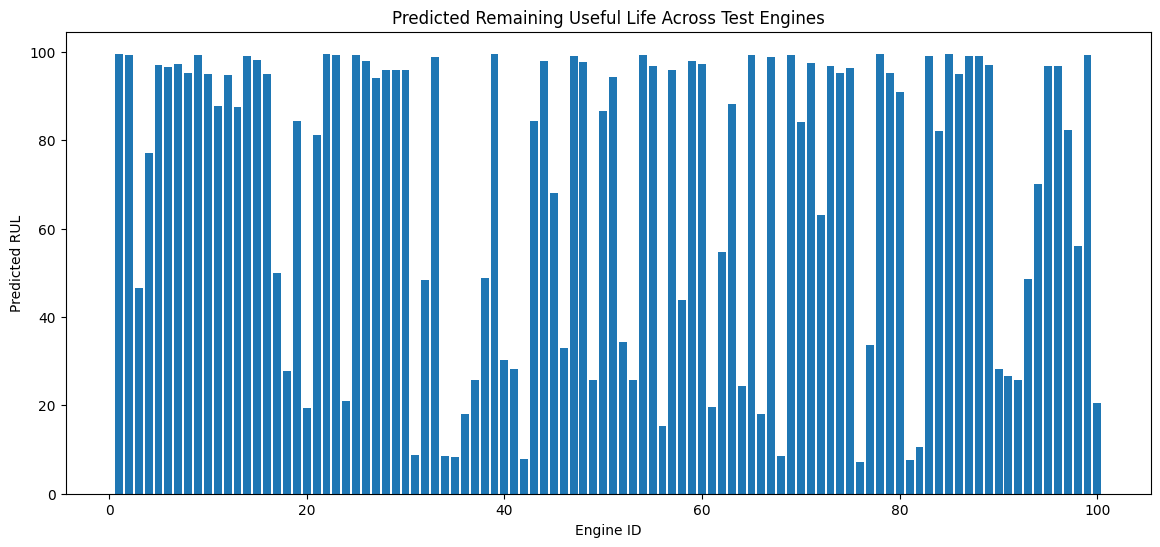

In [162]:
plt.figure(figsize=(14, 6))

plt.bar(
    final_engine_summary["Engine_ID"],
    final_engine_summary["Predicted_RUL"]
)

plt.xlabel("Engine ID")
plt.ylabel("Predicted RUL")
plt.title("Predicted Remaining Useful Life Across Test Engines")

plt.show()

In [ ]:
# 139 — Visualize Engine Health Scores


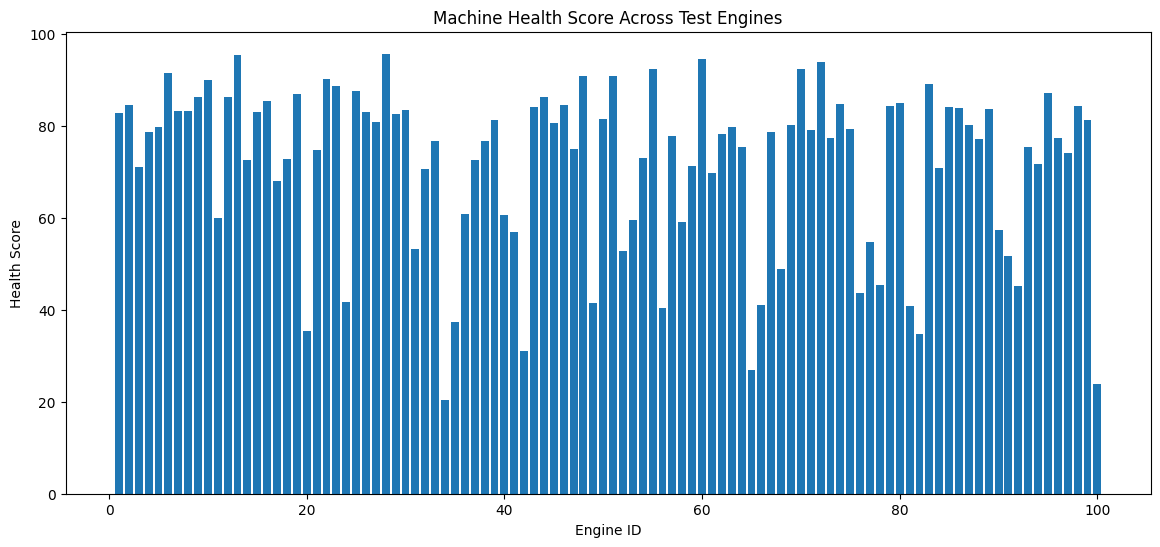

In [163]:
plt.figure(figsize=(14, 6))

plt.bar(
    final_engine_summary["Engine_ID"],
    final_engine_summary["Health_Score"]
)

plt.xlabel("Engine ID")
plt.ylabel("Health Score")
plt.title("Machine Health Score Across Test Engines")

plt.show()

In [ ]:
# 140 — Create Model Storage Directory


In [164]:
import os

models_path = "../models"

os.makedirs(
    models_path,
    exist_ok=True
)

print(
    "Models directory is ready:",
    os.path.abspath(models_path)
)

Models directory is ready: c:\Users\win 10-11\Desktop\Predictive_Maintenance\models


In [ ]:
# 141 — Save Final RUL GRU Model


In [165]:
rul_model_path = (
    "../models/final_rul_gru_cap100.keras"
)

best_gru_cap_model.save(
    rul_model_path
)

print(
    "RUL model saved successfully."
)
print(rul_model_path)

RUL model saved successfully.
../models/final_rul_gru_cap100.keras


In [ ]:
# 142 — Save Failure Risk GRU Model


In [166]:
risk_model_path = (
    "../models/failure_risk_gru.keras"
)

risk_gru_model.save(
    risk_model_path
)

print(
    "Failure Risk model saved successfully."
)
print(risk_model_path)

Failure Risk model saved successfully.
../models/failure_risk_gru.keras


In [ ]:
# 143 — Save Scalers and Isolation Forest


In [167]:
import joblib

joblib.dump(
    dl_scaler,
    "../models/dl_scaler.pkl"
)

joblib.dump(
    anomaly_scaler,
    "../models/anomaly_scaler.pkl"
)

joblib.dump(
    isolation_forest,
    "../models/isolation_forest.pkl"
)

print("All preprocessing objects saved successfully.")

All preprocessing objects saved successfully.


In [ ]:
# 144 — Save Final Engine Health Summary


In [168]:
dashboard_path = (
    "../data/processed/"
    "engine_health_summary.csv"
)

final_engine_summary.to_csv(
    dashboard_path,
    index=False
)

print(
    "Dashboard dataset saved successfully."
)
print(dashboard_path)

Dashboard dataset saved successfully.
../data/processed/engine_health_summary.csv


In [ ]:
# 145 — Verify Saved Project Artifacts


In [169]:
print("Saved Project Artifacts")
print("=======================")

for file_name in [
    "final_rul_gru_cap100.keras",
    "failure_risk_gru.keras",
    "dl_scaler.pkl",
    "anomaly_scaler.pkl",
    "isolation_forest.pkl"
]:

    file_path = os.path.join(
        models_path,
        file_name
    )

    print(
        f"{file_name}:",
        "✓ Saved" if os.path.exists(file_path)
        else "✗ Missing"
    )

print(
    "engine_health_summary.csv:",
    "✓ Saved"
    if os.path.exists(dashboard_path)
    else "✗ Missing"
)

Saved Project Artifacts
final_rul_gru_cap100.keras: ✓ Saved
failure_risk_gru.keras: ✓ Saved
dl_scaler.pkl: ✓ Saved
anomaly_scaler.pkl: ✓ Saved
isolation_forest.pkl: ✓ Saved
engine_health_summary.csv: ✓ Saved


In [ ]:
# 147 — Rebuild Final Engine Summary Correctly

# Get the latest observed cycle for every test engine

In [170]:
latest_cycle_status = (
    test_df
    .sort_values(["Engine_ID", "Cycle"])
    .groupby("Engine_ID")
    .tail(1)
    [
        [
            "Engine_ID",
            "Cycle",
            "Anomaly_Score",
            "Anomaly_Status",
            "Health_Score"
        ]
    ]
    .rename(
        columns={
            "Cycle": "Latest_Cycle"
        }
    )
    .reset_index(drop=True)
)

# Get the latest RUL and risk prediction for every engine
latest_engine_predictions = (
    sequence_meta
    .sort_values(["Engine_ID", "End_Cycle"])
    .groupby("Engine_ID")
    .tail(1)
    .reset_index(drop=True)
)

# Rename End_Cycle to avoid confusion
latest_engine_predictions = (
    latest_engine_predictions
    .rename(
        columns={
            "End_Cycle": "Prediction_End_Cycle"
        }
    )
)

# Get engine-level anomaly statistics
engine_anomaly_stats = (
    test_df
    .groupby("Engine_ID")
    .agg(
        Anomalous_Cycles=(
            "Anomaly_Prediction",
            lambda x: (x == -1).sum()
        ),
        Total_Cycles=("Cycle", "count"),
        Average_Anomaly_Score=(
            "Anomaly_Score",
            "mean"
        ),
        Average_Health_Score=(
            "Health_Score",
            "mean"
        )
    )
    .reset_index()
)

engine_anomaly_stats["Anomaly_Rate"] = (
    engine_anomaly_stats["Anomalous_Cycles"]
    / engine_anomaly_stats["Total_Cycles"]
)

# Combine everything
final_engine_summary = (
    latest_engine_predictions[
        [
            "Engine_ID",
            "Prediction_End_Cycle",
            "Predicted_RUL",
            "Risk_Level"
        ]
    ]
    .merge(
        latest_cycle_status,
        on="Engine_ID",
        how="left"
    )
    .merge(
        engine_anomaly_stats[
            [
                "Engine_ID",
                "Anomalous_Cycles",
                "Total_Cycles",
                "Average_Anomaly_Score",
                "Average_Health_Score",
                "Anomaly_Rate"
            ]
        ],
        on="Engine_ID",
        how="left"
    )
)

final_engine_summary = (
    final_engine_summary
    .sort_values("Engine_ID")
    .reset_index(drop=True)
)

display(
    final_engine_summary.head(10)
)

,Engine_ID,Prediction_End_Cycle,Predicted_RUL,Risk_Level,Latest_Cycle,Anomaly_Score,Anomaly_Status,Health_Score,Anomalous_Cycles,Total_Cycles,Average_Anomaly_Score,Average_Health_Score,Anomaly_Rate
0,1,-1.125507,99.488708,Low Risk,31,0.140145,Normal,82.736268,0,31,0.129289,78.553991,0.000000
1,2,-0.867027,99.206772,Low Risk,49,0.145045,Normal,84.624065,0,49,0.143364,83.976529,0.000000
2,3,0.238695,46.610477,Medium Risk,126,0.109757,Normal,71.028944,0,126,0.144512,84.418601,0.000000
3,4,-0.048506,77.040825,Low Risk,106,0.129602,Normal,78.674610,0,106,0.151130,86.968322,0.000000
4,5,-0.163386,97.018295,Low Risk,98,0.132218,Normal,79.682334,0,98,0.150907,86.882619,0.000000
5,6,-0.062866,96.647827,Low Risk,105,0.162736,Normal,91.439675,0,105,0.152628,87.545376,0.000000
6,7,0.726936,97.376480,Low Risk,160,0.141661,Normal,83.320164,1,160,0.115494,73.239251,0.006250
7,8,0.813096,95.299210,Low Risk,166,0.141674,Normal,83.325526,0,166,0.144100,84.260025,0.000000
8,9,-0.780867,99.346382,Low Risk,55,0.149113,Normal,86.191293,0,55,0.147795,85.683562,0.000000
9,10,1.186456,94.993019,Low Risk,192,0.159137,Normal,90.053143,2,192,0.122277,75.852303,0.010417


In [ ]:
# 148 — Verify Final Engine Summary


In [171]:
print("Number of engines:", len(final_engine_summary))

print("\nFirst engine:")
display(
    final_engine_summary[
        final_engine_summary["Engine_ID"] == 1
    ]
)

print("\nMissing values:")
print(
    final_engine_summary.isnull().sum()
)

Number of engines: 100

First engine:


,Engine_ID,Prediction_End_Cycle,Predicted_RUL,Risk_Level,Latest_Cycle,Anomaly_Score,Anomaly_Status,Health_Score,Anomalous_Cycles,Total_Cycles,Average_Anomaly_Score,Average_Health_Score,Anomaly_Rate
0,1,-1.125507,99.488708,Low Risk,31,0.140145,Normal,82.736268,0,31,0.129289,78.553991,0.0



Missing values:
Engine_ID                0
Prediction_End_Cycle     0
Predicted_RUL            0
Risk_Level               0
Latest_Cycle             0
Anomaly_Score            0
Anomaly_Status           0
Health_Score             0
Anomalous_Cycles         0
Total_Cycles             0
Average_Anomaly_Score    0
Average_Health_Score     0
Anomaly_Rate             0
dtype: int64


In [ ]:
# 149 — Update Dashboard Dataset


In [172]:
dashboard_path = (
    "../data/processed/"
    "engine_health_summary.csv"
)

final_engine_summary.to_csv(
    dashboard_path,
    index=False
)

print("Dashboard dataset updated successfully.")

Dashboard dataset updated successfully.
